## Main Setup

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:


evaluation_methods = {
    "deletion": "Deletion",
    "insertion": "Insertion",
    "negative": "Negative Perturbation",
}

replacement_strategies = {
    "black-5": "Black masking", 
    "minimum-intensity": "Minimum intensity",
    "white-5": "White masking", 
    "gaussian_blur": "Gaussian Blur",
    "attention_mask" : "Attention Mask",  
}

xai_methods = {
    "gradcam": "Grad-CAM",
    "last_layer": "Last-layer attention", 
    "slice_weighted_rollout": "Attention rollout" 
}

colors = {
    "gradcam": "#1f77b4",              # blue
    "last_layer": "#ff7f0e",           # orange
    "slice_weighted_rollout": "#2ca02c"  # green
}

In [3]:
base_path = Path("/home/jovyan/work/MST/results/DINOv3ViTB/evaluation_results")

In [4]:
test_data = np.load("/home/jovyan/work/MST/results/DINOv3ViTB/evaluation_results/deletion/deletion_curves/gradcam/attention_mask/02F4A1FB_left_curve_attention_mask.npy", allow_pickle=True).item()

In [5]:
test_data.keys()

dict_keys(['percentages', 'raw_logits', 'confidences', 'normalized_confidences', 'predicted_class', 'predicted_confidences', 'predicted_normalized_confidences', 'auc', 'replacement'])

## Mean Average

### Deletion
Method Comparison, single strategy

#### One Strategy
Black Masking

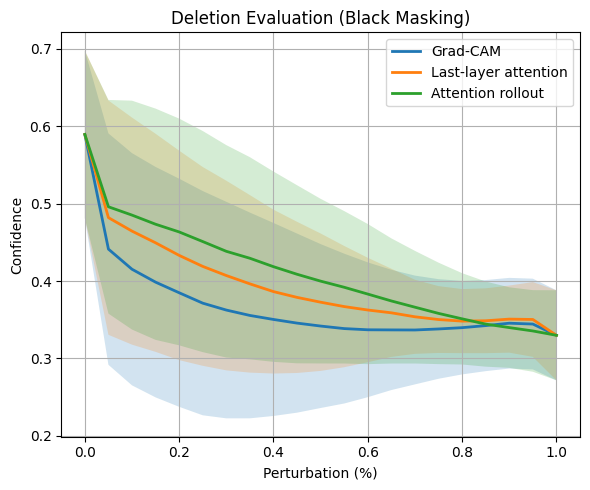

In [6]:
evaluation_metric = "deletion"
strategy = "black-5"  # first graph should use ONE strategy

# ===== PLOT =====
plt.figure(figsize=(6,5))

for method_key, method_name in xai_methods.items():

    curve_dir = base_path / evaluation_metric / f"{evaluation_metric}_curves" / method_key / strategy

    curves = []
    percentages = None

    for f in curve_dir.glob("*.npy"):
        data = np.load(f, allow_pickle=True).item()
        curves.append(data["predicted_confidences"])

        if percentages is None:
            percentages = data["percentages"]

    if len(curves) == 0:
        continue

    curves = np.array(curves)

    # ===== MEAN CURVE =====
    mean_curve = curves.mean(axis=0)

    # ===== OPTIONAL: STD =====
    std_curve = curves.std(axis=0)

    # ===== PLOT =====
    # plt.plot(percentages, mean_curve, label=method_name)
    plt.plot(percentages,
             mean_curve,
             label=method_name,
             color=colors[method_key],
             linewidth=2)
    plt.fill_between(percentages, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)

# ===== STYLE =====
plt.xlabel("Perturbation (%)")
plt.ylabel("Confidence")
plt.title("Deletion Evaluation (Black Masking)")
plt.legend()
plt.grid(True)
# plt.ylim(0, 1)

plt.tight_layout()
plt.show()

#### Strategies per graph

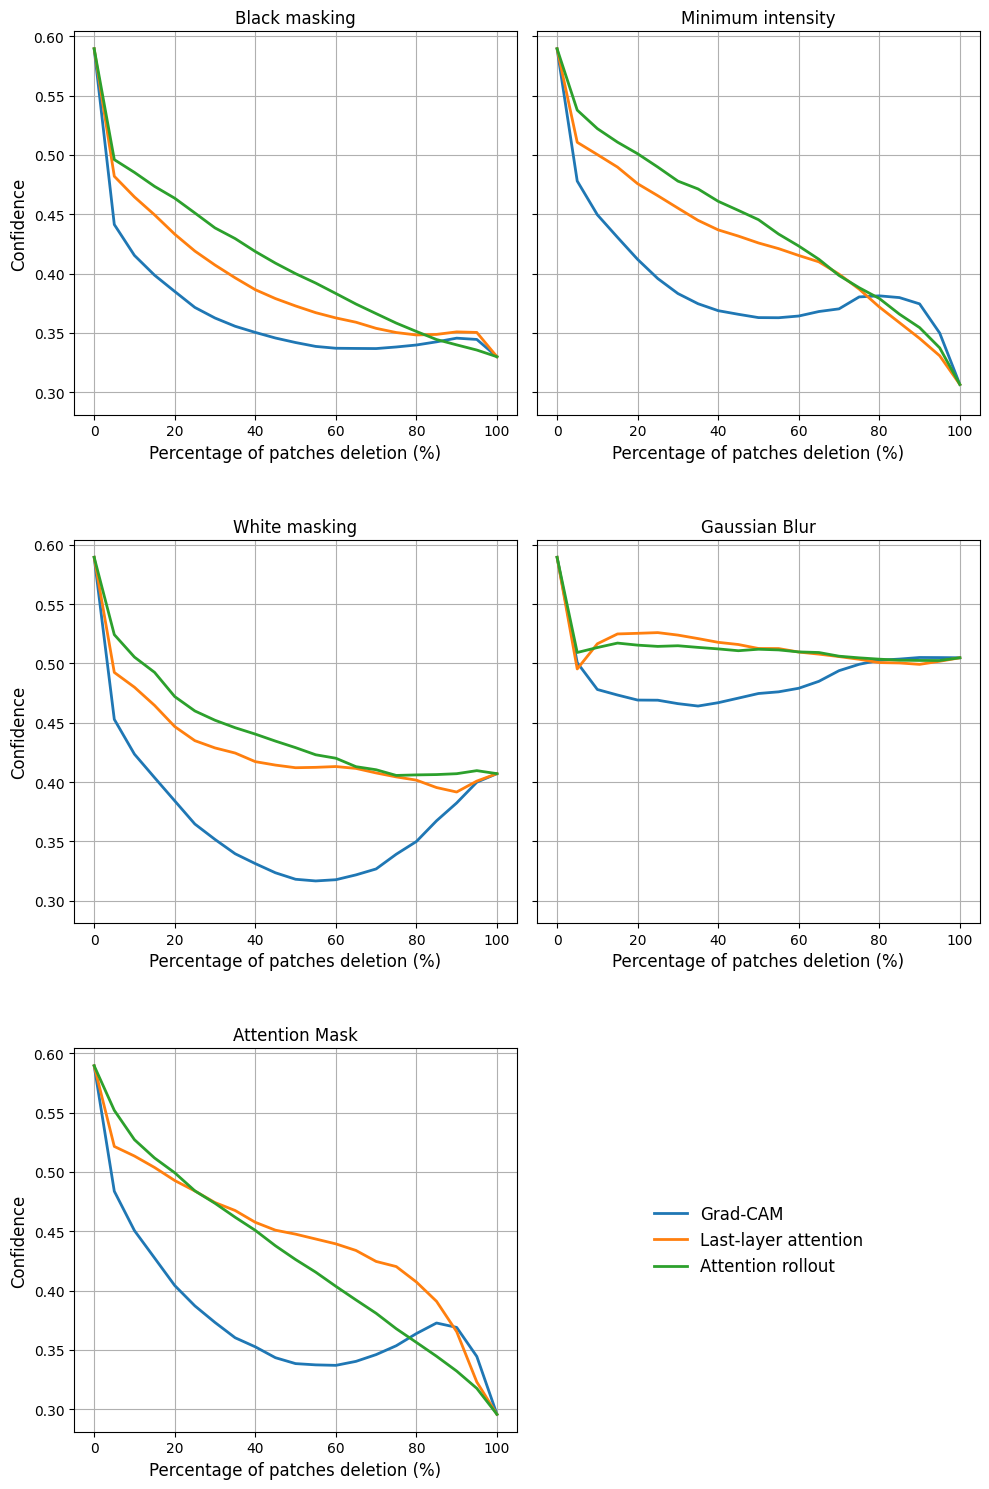

In [7]:
evaluation_metric = "deletion"
OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# ===== SETUP =====
strategies = list(replacement_strategies.items())
n_strategies = len(strategies)

# Create 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(10, 15), sharey=True)

# Flatten axes for easy indexing
axes = axes.flatten()

# ===== LOOP =====
for i, (strategy_key, strategy_name) in enumerate(strategies):
    ax = axes[i]

    for method_key, method_name in xai_methods.items():

        curve_dir = base_path / evaluation_metric / f"{evaluation_metric}_curves" / method_key / strategy_key

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()
            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)

        # Mean curve
        mean_curve = curves.mean(axis=0)

        ax.plot(percentages*100,
                mean_curve,
                label=method_name,
                color=colors[method_key],
                linewidth=2)
        
        # std_curve = curves.std(axis=0)

        # ax.fill_between(
        #     percentages*100,
        #     mean_curve - std_curve,
        #     mean_curve + std_curve,
        #     color=colors[method_key],
        #     alpha=0.2
        # )

    # Subplot formatting
    ax.set_title(strategy_name)
    ax.set_xlabel(f"Percentage of patches {evaluation_metric} (%)", fontsize=12)
    ax.grid(True)

# # ===== REMOVE EMPTY PLOT =====
# for j in range(n_strategies, len(axes)):
#     fig.delaxes(axes[j])

# ===== USE LAST AXIS FOR LEGEND =====
legend_ax = axes[-1]
# Turn off axis
legend_ax.axis("off")
# Get legend handles
handles, labels = axes[0].get_legend_handles_labels()
# Place legend inside this subplot
legend_ax.legend(handles, labels, loc="center", frameon=False, fontsize=12)

# ===== SHARED LABEL =====
axes[0].set_ylabel("Confidence", fontsize=12)
axes[2].set_ylabel("Confidence", fontsize=12)
axes[4].set_ylabel("Confidence", fontsize=12)

# # ===== LEGEND =====
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="lower right", ncol=3)

# ===== TITLE =====
# fig.suptitle(f"{evaluation_methods[evaluation_metric]} Evaluation (Mean Curves)", fontsize=14)

# plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.tight_layout(h_pad=4)
# plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{evaluation_metric}_evaluation_curves.jpg", dpi=150)
plt.show()

In [8]:
from sklearn.metrics import auc
import numpy as np
import pandas as pd

evaluation_metric = "deletion"

results = []

for strategy_key, strategy_name in replacement_strategies.items():
    for method_key, method_name in xai_methods.items():

        curve_dir = (
            base_path /
            evaluation_metric /
            f"{evaluation_metric}_curves" /
            method_key /
            strategy_key
        )

        sample_aucs = []
        class_curves = {}

        percentages = None

        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()

            confidences = np.array(data["predicted_confidences"])
            percentages = np.array(data["percentages"])

            # assuming class label stored in file
            predicted_class = data["predicted_class"]

            # -------------------------
            # Micro-average
            # -------------------------
            sample_auc = auc(percentages, confidences)
            sample_aucs.append(sample_auc)

            # -------------------------
            # Store for macro-average
            # -------------------------
            if predicted_class not in class_curves:
                class_curves[predicted_class] = []

            class_curves[predicted_class].append(confidences)

        if len(sample_aucs) == 0:
            continue

        # ===== Micro-average =====
        sample_aucs = np.array(sample_aucs)
        micro_auc_mean = sample_aucs.mean()
        micro_auc_std = sample_aucs.std()

        # ===== Macro-average =====
        class_aucs = []

        for cls, curves in class_curves.items():
            curves = np.array(curves)

            # class mean curve
            mean_curve = curves.mean(axis=0)

            # class AUCC
            class_auc = auc(percentages, mean_curve)
            class_aucs.append(class_auc)

        class_aucs = np.array(class_aucs)

        macro_auc_mean = class_aucs.mean()
        macro_auc_std = class_aucs.std()

        results.append({
            "mode": evaluation_metric,
            "xai_method": method_key,
            "replacement": strategy_key,
            "micro_mean": micro_auc_mean,
            "micro_std": micro_auc_std,
            "macro_mean": macro_auc_mean,
            "macro_std": macro_auc_std,
            "count": len(sample_aucs)
        })

df_results = pd.DataFrame(results)
print(df_results)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.11/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found

        mode              xai_method        replacement  micro_mean  \
0   deletion                 gradcam            black-5    0.364324   
1   deletion              last_layer            black-5    0.391990   
2   deletion  slice_weighted_rollout            black-5    0.408431   
3   deletion                 gradcam  minimum-intensity    0.389948   
4   deletion              last_layer  minimum-intensity    0.426123   
5   deletion  slice_weighted_rollout  minimum-intensity    0.440450   
6   deletion                 gradcam            white-5    0.365630   
7   deletion              last_layer            white-5    0.427585   
8   deletion  slice_weighted_rollout            white-5    0.442735   
9   deletion                 gradcam      gaussian_blur    0.486421   
10  deletion              last_layer      gaussian_blur    0.513340   
11  deletion  slice_weighted_rollout      gaussian_blur    0.511571   
12  deletion                 gradcam     attention_mask    0.376370   
13  de

In [9]:
import pandas as pd
# Create DataFrame
df_summary_auc_deletion = pd.DataFrame(results)

# Optional sorting
df_summary_auc_deletion = df_summary_auc_deletion.sort_values(
    by=["mode", "xai_method", "replacement"]
).reset_index(drop=True)

df_summary_auc_deletion

,mode,xai_method,replacement,micro_mean,micro_std,macro_mean,macro_std,count
0,deletion,gradcam,attention_mask,0.376370,0.117154,0.336221,0.109972,116
1,deletion,gradcam,black-5,0.364324,0.091804,0.323851,0.085610,116
2,deletion,gradcam,gaussian_blur,0.486421,0.168117,0.403012,0.132830,116
3,deletion,gradcam,minimum-intensity,0.389948,0.130506,0.323137,0.114793,116
4,deletion,gradcam,white-5,0.365630,0.115968,0.320291,0.097645,116
5,deletion,last_layer,attention_mask,0.445156,0.112504,0.407419,0.117943,116
6,deletion,last_layer,black-5,0.391990,0.076906,0.358688,0.071904,116
7,deletion,last_layer,gaussian_blur,0.513340,0.169713,0.433494,0.127760,116
8,deletion,last_layer,minimum-intensity,0.426123,0.099752,0.374806,0.089227,116
9,deletion,last_layer,white-5,0.427585,0.105150,0.389607,0.100813,116


In [10]:
replacement_order = [
    "black-5",
    "minimum-intensity",
    "white-5",
    "gaussian_blur",
    "attention_mask"
]

# Set custom order
df_summary_auc_deletion["replacement"] = pd.Categorical(
    df_summary_auc_deletion["replacement"],
    categories=replacement_order,
    ordered=True
)

# Sort dataframe
df_summary_auc_deletion = df_summary_auc_deletion.sort_values("replacement").reset_index(drop=True)

In [11]:
df_summary_auc_deletion['micro_mean'] = df_summary_auc_deletion['micro_mean'].round(3)
df_summary_auc_deletion['micro_std'] = df_summary_auc_deletion['micro_std'].round(3)
df_summary_auc_deletion['macro_mean'] = df_summary_auc_deletion['macro_mean'].round(3)
df_summary_auc_deletion['macro_std'] = df_summary_auc_deletion['macro_std'].round(3)


df_summary_auc_deletion

,mode,xai_method,replacement,micro_mean,micro_std,macro_mean,macro_std,count
0,deletion,gradcam,black-5,0.364,0.092,0.324,0.086,116
1,deletion,last_layer,black-5,0.392,0.077,0.359,0.072,116
2,deletion,slice_weighted_rollout,black-5,0.408,0.093,0.368,0.089,116
3,deletion,gradcam,minimum-intensity,0.390,0.131,0.323,0.115,116
4,deletion,last_layer,minimum-intensity,0.426,0.100,0.375,0.089,116
5,deletion,slice_weighted_rollout,minimum-intensity,0.440,0.107,0.388,0.089,116
6,deletion,gradcam,white-5,0.366,0.116,0.320,0.098,116
7,deletion,last_layer,white-5,0.428,0.105,0.390,0.101,116
8,deletion,slice_weighted_rollout,white-5,0.443,0.110,0.398,0.096,116
9,deletion,gradcam,gaussian_blur,0.486,0.168,0.403,0.133,116


### Insertion

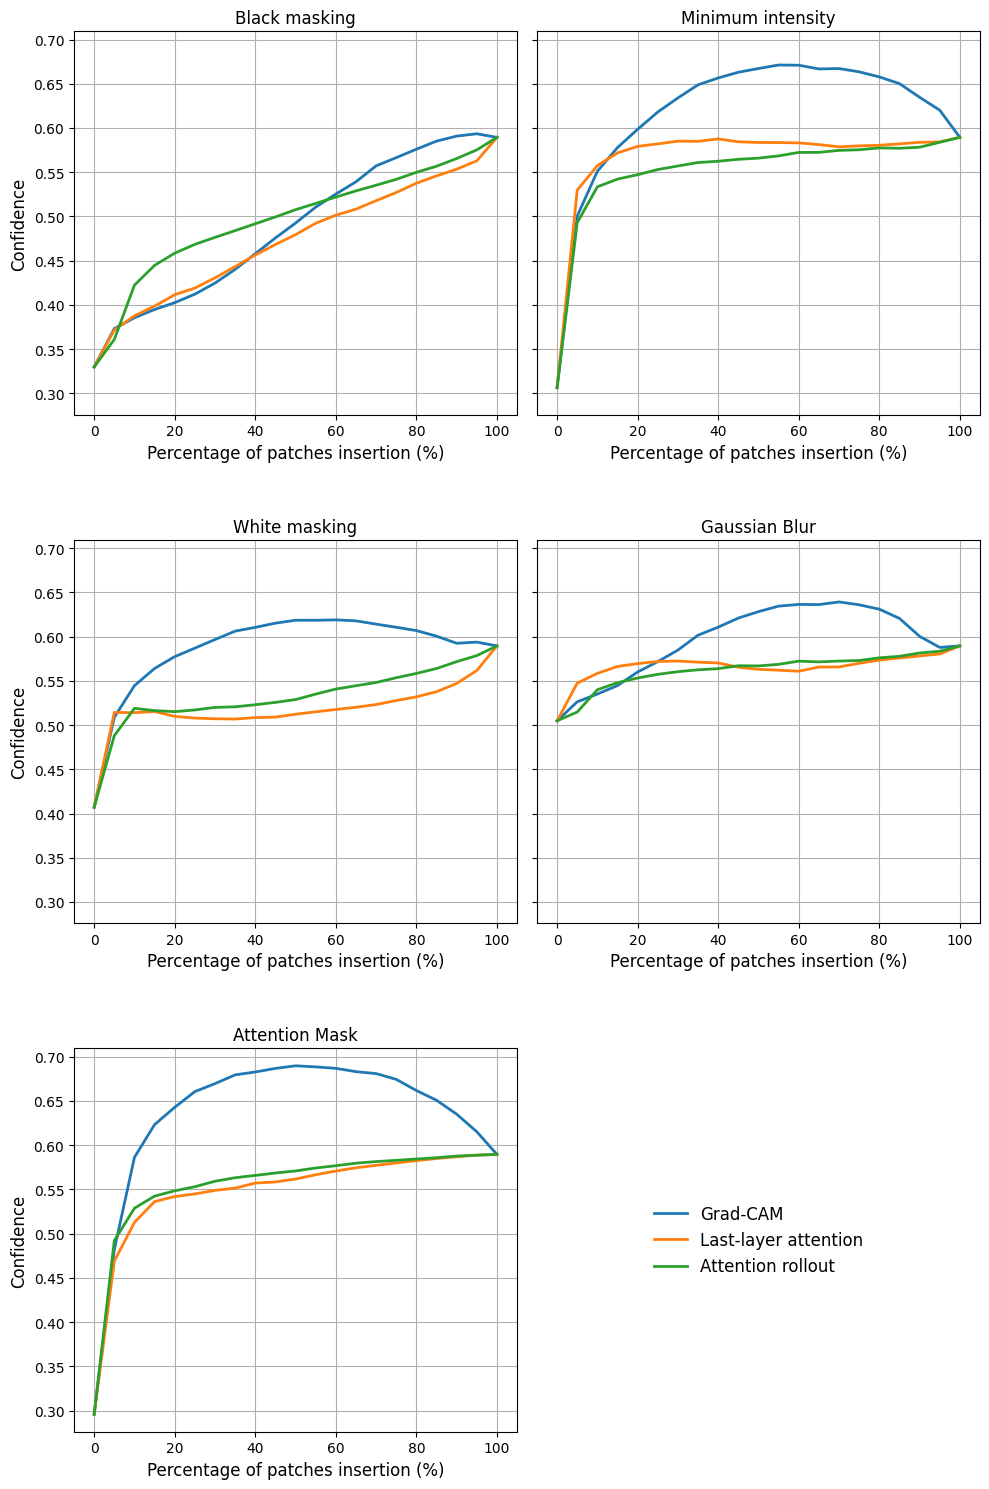

In [12]:
evaluation_metric = "insertion"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# ===== SETUP =====
strategies = list(replacement_strategies.items())
n_strategies = len(strategies)

# Create 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(10, 15), sharey=True)

# Flatten axes for easy indexing
axes = axes.flatten()

# ===== LOOP =====
for i, (strategy_key, strategy_name) in enumerate(strategies):
    ax = axes[i]

    for method_key, method_name in xai_methods.items():

        curve_dir = base_path / evaluation_metric / f"{evaluation_metric}_curves" / method_key / strategy_key

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()
            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)

        # Mean curve
        mean_curve = curves.mean(axis=0)

        ax.plot(percentages*100,
                mean_curve,
                label=method_name,
                color=colors[method_key],
                linewidth=2)
        
        # std_curve = curves.std(axis=0)

        # ax.fill_between(
        #     percentages*100,
        #     mean_curve - std_curve,
        #     mean_curve + std_curve,
        #     color=colors[method_key],
        #     alpha=0.2
        # )

    # Subplot formatting
    ax.set_title(strategy_name)
    ax.set_xlabel(f"Percentage of patches {evaluation_metric} (%)", fontsize=12)
    ax.grid(True)

# # ===== REMOVE EMPTY PLOT =====
# for j in range(n_strategies, len(axes)):
#     fig.delaxes(axes[j])

# ===== USE LAST AXIS FOR LEGEND =====
legend_ax = axes[-1]
# Turn off axis
legend_ax.axis("off")
# Get legend handles
handles, labels = axes[0].get_legend_handles_labels()
# Place legend inside this subplot
legend_ax.legend(handles, labels, loc="center", frameon=False, fontsize=12)

# ===== SHARED LABEL =====
axes[0].set_ylabel("Confidence", fontsize=12)
axes[2].set_ylabel("Confidence", fontsize=12)
axes[4].set_ylabel("Confidence", fontsize=12)

# # ===== LEGEND =====
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="lower right", ncol=3)

# ===== TITLE =====
# fig.suptitle(f"{evaluation_methods[evaluation_metric]} Evaluation (Mean Curves)", fontsize=14)

# plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.tight_layout(h_pad=4)
# plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{evaluation_metric}_evaluation_curves.jpg", dpi=150)
plt.show()

In [13]:
evaluation_metric = "insertion"

results = []

for strategy_key, strategy_name in replacement_strategies.items():
    for method_key, method_name in xai_methods.items():

        curve_dir = (
            base_path /
            evaluation_metric /
            f"{evaluation_metric}_curves" /
            method_key /
            strategy_key
        )

        sample_aucs = []
        class_curves = {}

        percentages = None

        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()

            confidences = np.array(data["predicted_confidences"])
            percentages = np.array(data["percentages"])

            # assuming class label stored in file
            predicted_class = data["predicted_class"]

            # -------------------------
            # Micro-average
            # -------------------------
            sample_auc = auc(percentages, confidences)
            sample_aucs.append(sample_auc)

            # -------------------------
            # Store for macro-average
            # -------------------------
            if predicted_class not in class_curves:
                class_curves[predicted_class] = []

            class_curves[predicted_class].append(confidences)

        if len(sample_aucs) == 0:
            continue

        # ===== Micro-average =====
        sample_aucs = np.array(sample_aucs)
        micro_auc_mean = sample_aucs.mean()
        micro_auc_std = sample_aucs.std()

        # ===== Macro-average =====
        class_aucs = []

        for cls, curves in class_curves.items():
            curves = np.array(curves)

            # class mean curve
            mean_curve = curves.mean(axis=0)

            # class AUCC
            class_auc = auc(percentages, mean_curve)
            class_aucs.append(class_auc)

        class_aucs = np.array(class_aucs)

        macro_auc_mean = class_aucs.mean()
        macro_auc_std = class_aucs.std()

        results.append({
            "mode": evaluation_metric,
            "xai_method": method_key,
            "replacement": strategy_key,
            "micro_mean": micro_auc_mean,
            "micro_std": micro_auc_std,
            "macro_mean": macro_auc_mean,
            "macro_std": macro_auc_std,
            "count": len(sample_aucs)
        })


# Create DataFrame
df_summary_auc_insertion = pd.DataFrame(results)

# Optional sorting
df_summary_auc_insertion = df_summary_auc_insertion.sort_values(
    by=["mode", "xai_method", "replacement"]
).reset_index(drop=True)


df_summary_auc_insertion["replacement"] = pd.Categorical(
    df_summary_auc_insertion["replacement"],
    categories=replacement_order,
    ordered=True
)

# Sort dataframe
df_summary_auc_insertion = df_summary_auc_insertion.sort_values("replacement").reset_index(drop=True)

df_summary_auc_insertion['micro_mean'] = df_summary_auc_insertion['micro_mean'].round(3)
df_summary_auc_insertion['micro_std'] = df_summary_auc_insertion['micro_std'].round(3)
df_summary_auc_insertion['macro_mean'] = df_summary_auc_insertion['macro_mean'].round(3)
df_summary_auc_insertion['macro_std'] = df_summary_auc_insertion['macro_std'].round(3)


df_summary_auc_insertion

,mode,xai_method,replacement,micro_mean,micro_std,macro_mean,macro_std,count
0,insertion,gradcam,black-5,0.488,0.079,0.472,0.034,116
1,insertion,last_layer,black-5,0.474,0.095,0.466,0.032,116
2,insertion,slice_weighted_rollout,black-5,0.498,0.106,0.522,0.074,116
3,insertion,gradcam,minimum-intensity,0.623,0.114,0.599,0.073,116
4,insertion,last_layer,minimum-intensity,0.572,0.127,0.554,0.088,116
5,insertion,slice_weighted_rollout,minimum-intensity,0.555,0.118,0.557,0.081,116
6,insertion,gradcam,white-5,0.590,0.099,0.582,0.039,116
7,insertion,last_layer,white-5,0.519,0.126,0.537,0.071,116
8,insertion,slice_weighted_rollout,white-5,0.533,0.108,0.544,0.059,116
9,insertion,gradcam,gaussian_blur,0.598,0.133,0.561,0.091,116


### Negative

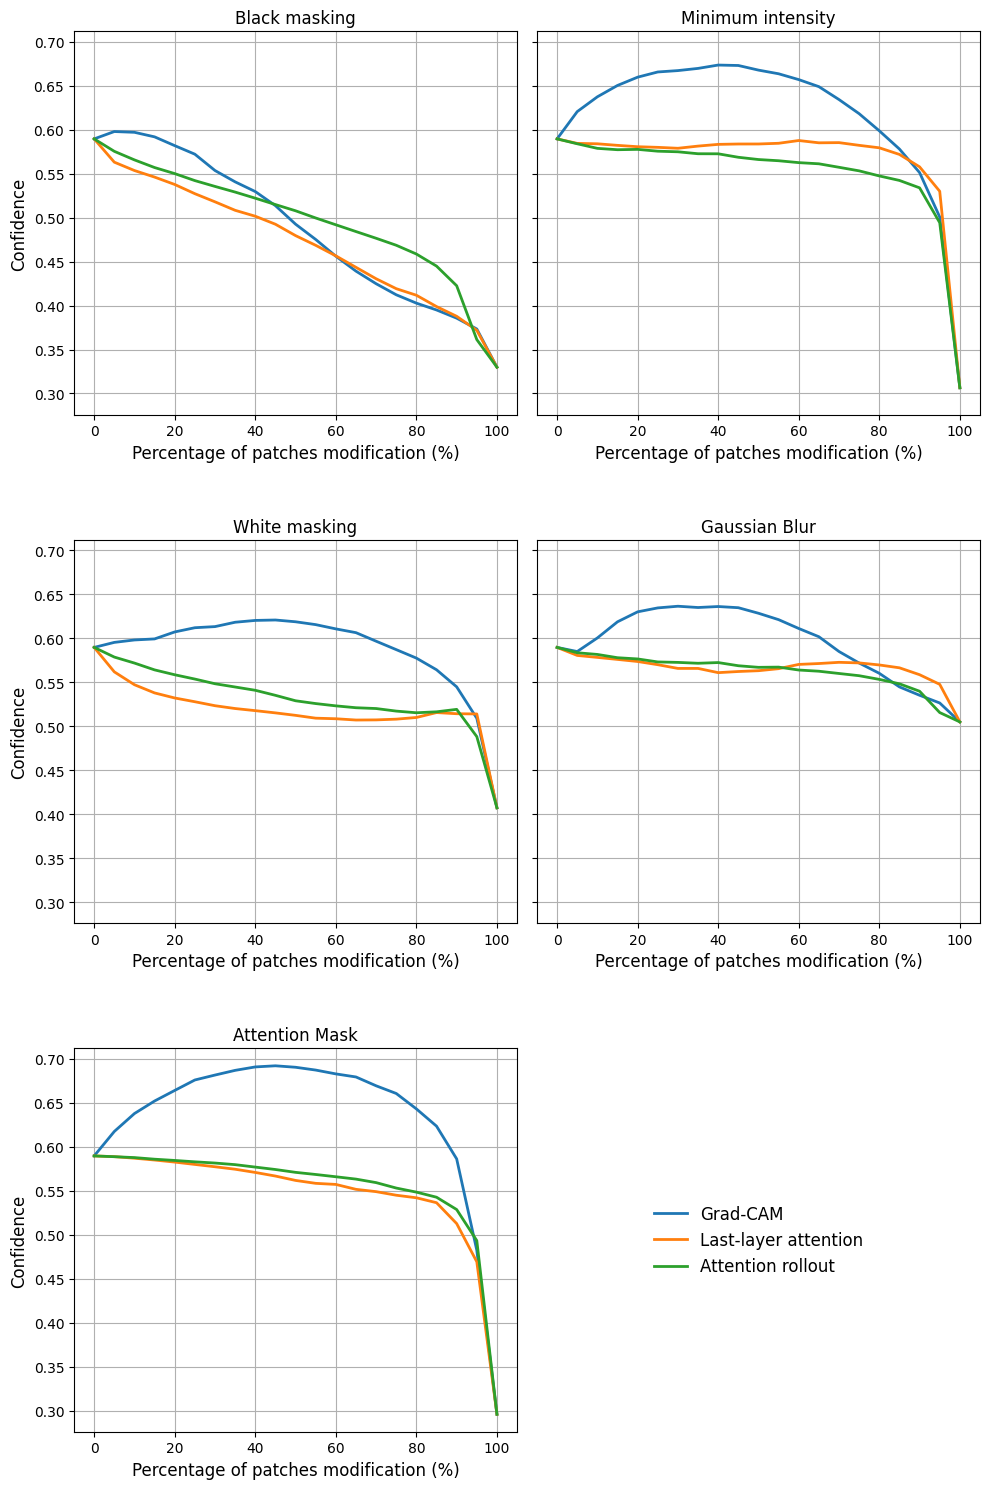

In [14]:
evaluation_metric = "negative"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# ===== SETUP =====
strategies = list(replacement_strategies.items())
n_strategies = len(strategies)

# Create 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(10, 15), sharey=True)

# Flatten axes for easy indexing
axes = axes.flatten()

# ===== LOOP =====
for i, (strategy_key, strategy_name) in enumerate(strategies):
    ax = axes[i]

    for method_key, method_name in xai_methods.items():

        curve_dir = base_path / evaluation_metric / f"{evaluation_metric}_curves" / method_key / strategy_key

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()
            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)

        # Mean curve
        mean_curve = curves.mean(axis=0)

        ax.plot(percentages*100,
                mean_curve,
                label=method_name,
                color=colors[method_key],
                linewidth=2)
        
        # std_curve = curves.std(axis=0)

        # ax.fill_between(
        #     percentages*100,
        #     mean_curve - std_curve,
        #     mean_curve + std_curve,
        #     color=colors[method_key],
        #     alpha=0.2
        # )

    # Subplot formatting
    ax.set_title(strategy_name)
    ax.set_xlabel(f"Percentage of patches modification (%)", fontsize=12)
    ax.grid(True)

# # ===== REMOVE EMPTY PLOT =====
# for j in range(n_strategies, len(axes)):
#     fig.delaxes(axes[j])

# ===== USE LAST AXIS FOR LEGEND =====
legend_ax = axes[-1]
# Turn off axis
legend_ax.axis("off")
# Get legend handles
handles, labels = axes[0].get_legend_handles_labels()
# Place legend inside this subplot
legend_ax.legend(handles, labels, loc="center", frameon=False, fontsize=12)

# ===== SHARED LABEL =====
axes[0].set_ylabel("Confidence", fontsize=12)
axes[2].set_ylabel("Confidence", fontsize=12)
axes[4].set_ylabel("Confidence", fontsize=12)

# # ===== LEGEND =====
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="lower right", ncol=3)

# ===== TITLE =====
# fig.suptitle(f"{evaluation_methods[evaluation_metric]} Evaluation (Mean Curves)", fontsize=14)

# plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.tight_layout(h_pad=4)
# plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{evaluation_metric}_evaluation_curves.jpg", dpi=150)
plt.show()

In [15]:
evaluation_metric = "negative"

results = []

for strategy_key, strategy_name in replacement_strategies.items():
    for method_key, method_name in xai_methods.items():

        curve_dir = (
            base_path /
            evaluation_metric /
            f"{evaluation_metric}_curves" /
            method_key /
            strategy_key
        )

        sample_aucs = []
        class_curves = {}

        percentages = None

        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()

            confidences = np.array(data["predicted_confidences"])
            percentages = np.array(data["percentages"])

            # assuming class label stored in file
            predicted_class = data["predicted_class"]

            # -------------------------
            # Micro-average
            # -------------------------
            sample_auc = auc(percentages, confidences)
            sample_aucs.append(sample_auc)

            # -------------------------
            # Store for macro-average
            # -------------------------
            if predicted_class not in class_curves:
                class_curves[predicted_class] = []

            class_curves[predicted_class].append(confidences)

        if len(sample_aucs) == 0:
            continue

        # ===== Micro-average =====
        sample_aucs = np.array(sample_aucs)
        micro_auc_mean = sample_aucs.mean()
        micro_auc_std = sample_aucs.std()

        # ===== Macro-average =====
        class_aucs = []

        for cls, curves in class_curves.items():
            curves = np.array(curves)

            # class mean curve
            mean_curve = curves.mean(axis=0)

            # class AUCC
            class_auc = auc(percentages, mean_curve)
            class_aucs.append(class_auc)

        class_aucs = np.array(class_aucs)

        macro_auc_mean = class_aucs.mean()
        macro_auc_std = class_aucs.std()

        results.append({
            "mode": evaluation_metric,
            "xai_method": method_key,
            "replacement": strategy_key,
            "micro_mean": micro_auc_mean,
            "micro_std": micro_auc_std,
            "macro_mean": macro_auc_mean,
            "macro_std": macro_auc_std,
            "count": len(sample_aucs)
        })


# Create DataFrame
df_summary_auc_negative = pd.DataFrame(results)

# Optional sorting
df_summary_auc_negative = df_summary_auc_negative.sort_values(
    by=["mode", "xai_method", "replacement"]
).reset_index(drop=True)


df_summary_auc_negative["replacement"] = pd.Categorical(
    df_summary_auc_negative["replacement"],
    categories=replacement_order,
    ordered=True
)

# Sort dataframe
df_summary_auc_negative = df_summary_auc_negative.sort_values("replacement").reset_index(drop=True)

df_summary_auc_negative['micro_mean'] = df_summary_auc_negative['micro_mean'].round(3)
df_summary_auc_negative['micro_std'] = df_summary_auc_negative['micro_std'].round(3)
df_summary_auc_negative['macro_mean'] = df_summary_auc_negative['macro_mean'].round(3)
df_summary_auc_negative['macro_std'] = df_summary_auc_negative['macro_std'].round(3)


df_summary_auc_negative

,mode,xai_method,replacement,micro_mean,micro_std,macro_mean,macro_std,count
0,negative,gradcam,black-5,0.490,0.073,0.474,0.030,116
1,negative,last_layer,black-5,0.474,0.095,0.466,0.032,116
2,negative,slice_weighted_rollout,black-5,0.498,0.106,0.522,0.073,116
3,negative,gradcam,minimum-intensity,0.624,0.113,0.601,0.074,116
4,negative,last_layer,minimum-intensity,0.572,0.127,0.554,0.088,116
5,negative,slice_weighted_rollout,minimum-intensity,0.556,0.118,0.557,0.081,116
6,negative,gradcam,white-5,0.590,0.098,0.583,0.040,116
7,negative,last_layer,white-5,0.519,0.126,0.537,0.071,116
8,negative,slice_weighted_rollout,white-5,0.533,0.108,0.544,0.059,116
9,negative,gradcam,gaussian_blur,0.597,0.133,0.560,0.090,116


#### Drop Curve

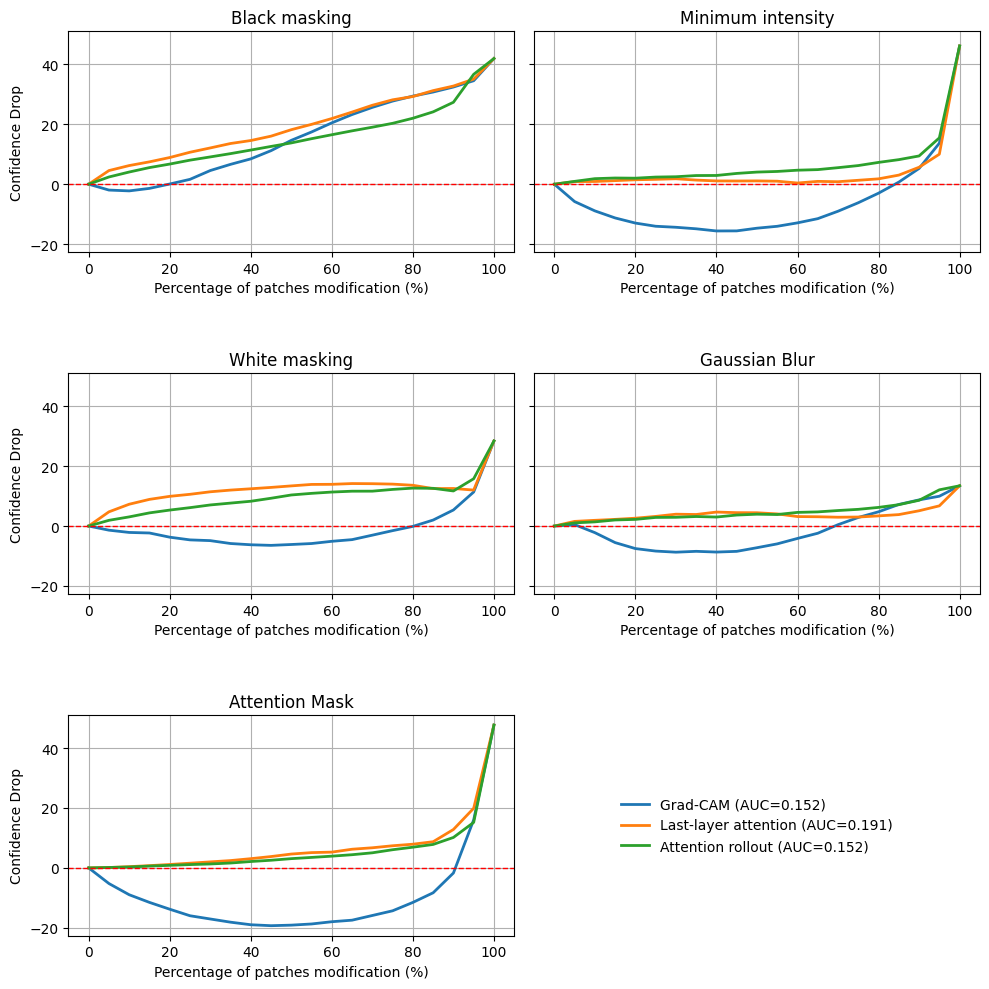

                  method           strategy  mean_auc  std_auc
0               Grad-CAM      Black masking     0.152    0.154
1   Last-layer attention      Black masking     0.191    0.117
2      Attention rollout      Black masking     0.152    0.099
3               Grad-CAM  Minimum intensity    -0.071    0.174
4   Last-layer attention  Minimum intensity     0.030    0.128
5      Attention rollout  Minimum intensity     0.057    0.099
6               Grad-CAM      White masking    -0.015    0.160
7   Last-layer attention      White masking     0.119    0.137
8      Attention rollout      White masking     0.094    0.080
9               Grad-CAM      Gaussian Blur    -0.018    0.182
10  Last-layer attention      Gaussian Blur     0.037    0.137
11     Attention rollout      Gaussian Blur     0.045    0.107
12              Grad-CAM     Attention Mask    -0.107    0.139
13  Last-layer attention     Attention Mask     0.062    0.069
14     Attention rollout     Attention Mask     0.050  

In [16]:
# ===== Negative Perturbation: Drop Curve + AUC =====

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import auc

evaluation_metric = "negative"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

strategies = list(replacement_strategies.items())
fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharey=True)
axes = axes.flatten()

# Store AUC results
results = []

for i, (strategy_key, strategy_name) in enumerate(strategies):
    ax = axes[i]

    for method_key, method_name in xai_methods.items():

        curve_dir = base_path / evaluation_metric / f"{evaluation_metric}_curves" / method_key / strategy_key

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()
            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)  # [N, T]

        # ===== DROP CURVE =====
        c0 = curves[:, 0:1]  # initial confidence
        drop_curves = (c0 - curves) / (c0 + 1e-8)

        # ===== MEAN CURVE =====
        mean_curve = drop_curves.mean(axis=0)

        # ===== AUC =====
        auc_scores = [auc(percentages, curve) for curve in drop_curves]
        mean_auc = np.mean(auc_scores)
        std_auc = np.std(auc_scores)

        results.append({
            "method": method_name,
            "strategy": strategy_name,
            "mean_auc": round(mean_auc, 3),
            "std_auc": round(std_auc, 3)
        })

        # ===== PLOT =====
        ax.plot(percentages * 100,
                mean_curve*100,
                label=f"{method_name} (AUC={mean_auc:.3f})",
                color=colors[method_key],
                linewidth=2)

    ax.axhline(y=0, linestyle="--", linewidth=1, color="red")
    ax.set_title(strategy_name)
    ax.set_xlabel("Percentage of patches modification (%)")
    ax.grid(True)

# ===== LEGEND PANEL =====
legend_ax = axes[-1]
legend_ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc="center", frameon=False)

# ===== Y LABEL =====
axes[0].set_ylabel("Confidence Drop")
axes[2].set_ylabel("Confidence Drop")
axes[4].set_ylabel("Confidence Drop")

plt.tight_layout(h_pad=4)
plt.savefig(OUTPUT_DIR / f"{evaluation_metric}_drop_curves_normalized.jpg", dpi=150)
plt.show()

# ===== PRINT RESULTS =====
import pandas as pd
df_results = pd.DataFrame(results)
print(df_results)

## Case Analysis

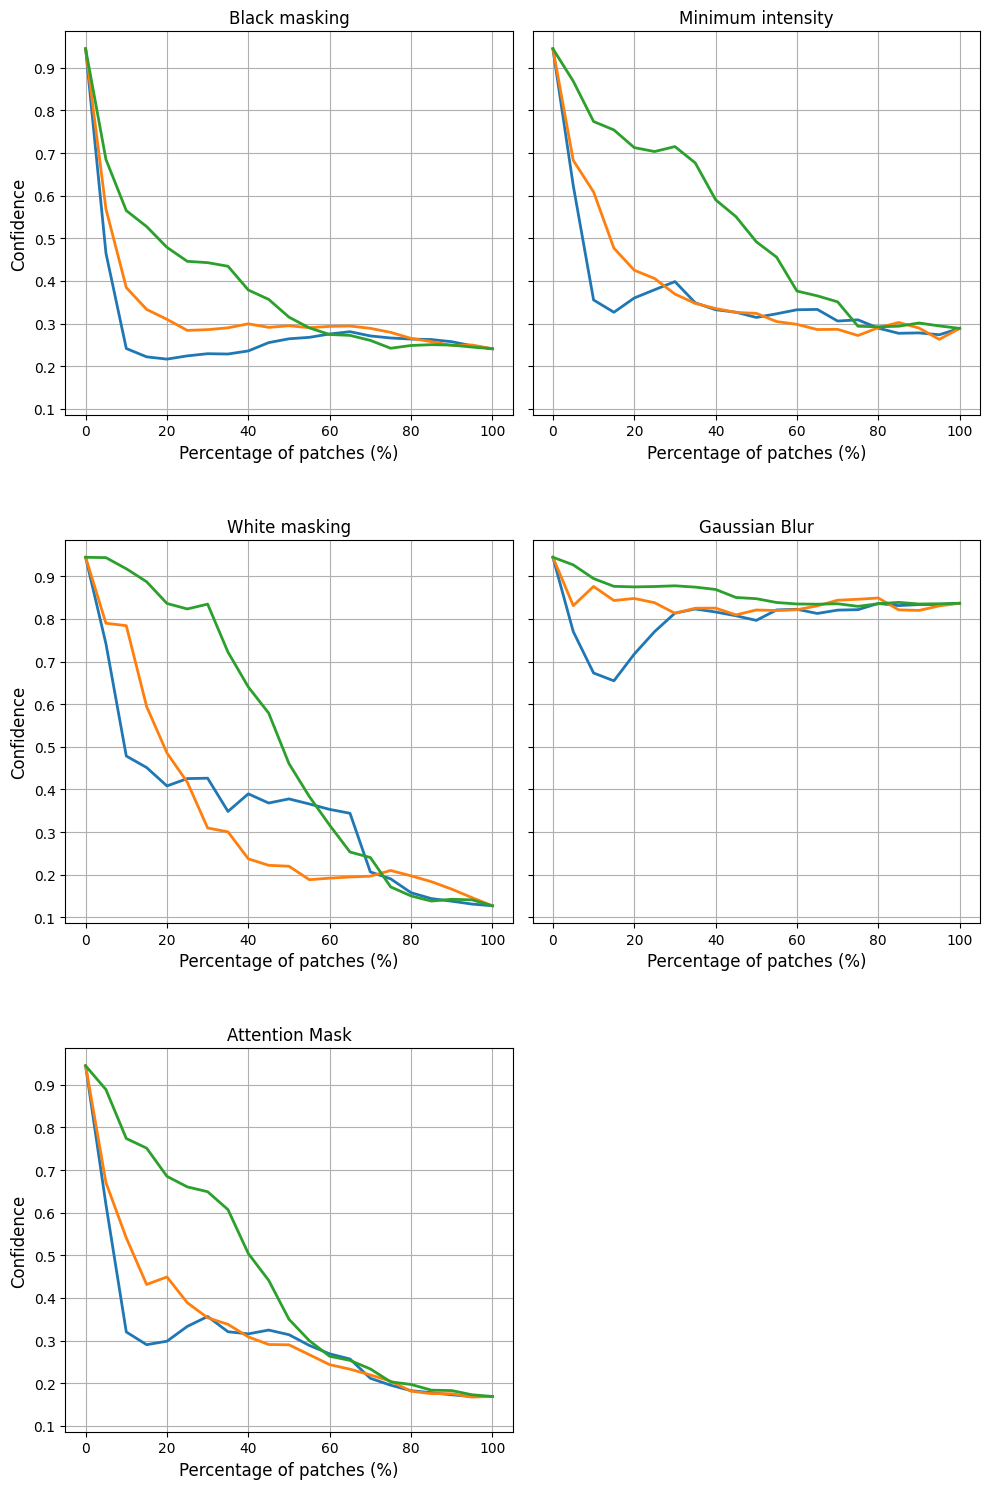

In [17]:
evaluation_metric = "deletion"  # or "insertion" / "negative"
UID = "ODELIA_TRICKS_0067_1_left"

strategies = list(replacement_strategies.items())

fig, axes = plt.subplots(3, 2, figsize=(10, 15), sharey=True)
axes = axes.flatten()

for i, (strategy_key, strategy_name) in enumerate(strategies):
    ax = axes[i]

    for method_key, method_name in xai_methods.items():

        curve_dir = base_path / evaluation_metric / f"{evaluation_metric}_curves" / method_key / strategy_key
        
        # Find file for this UID
        file_path = curve_dir / f"{UID}_curve_{strategy_key}.npy"

        if not file_path.exists():
            continue

        data = np.load(file_path, allow_pickle=True).item()
        curve = data["predicted_confidences"]
        percentages = data["percentages"]

        ax.plot(
            percentages * 100,
            curve,
            label=method_name,
            color=colors[method_key],
            linewidth=2
        )

    # Formatting
    ax.set_title(strategy_name)
    ax.set_xlabel("Percentage of patches (%)", fontsize=12)
    ax.grid(True)

# Remove unused subplot if needed
for j in range(len(strategies), len(axes)):
    fig.delaxes(axes[j])

# Legend in last panel
legend_ax = axes[-1]
legend_ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc="center", frameon=False)

# Y-label
axes[0].set_ylabel("Confidence", fontsize=12)
axes[2].set_ylabel("Confidence", fontsize=12)
axes[4].set_ylabel("Confidence", fontsize=12)

plt.tight_layout(h_pad=4)
plt.show()

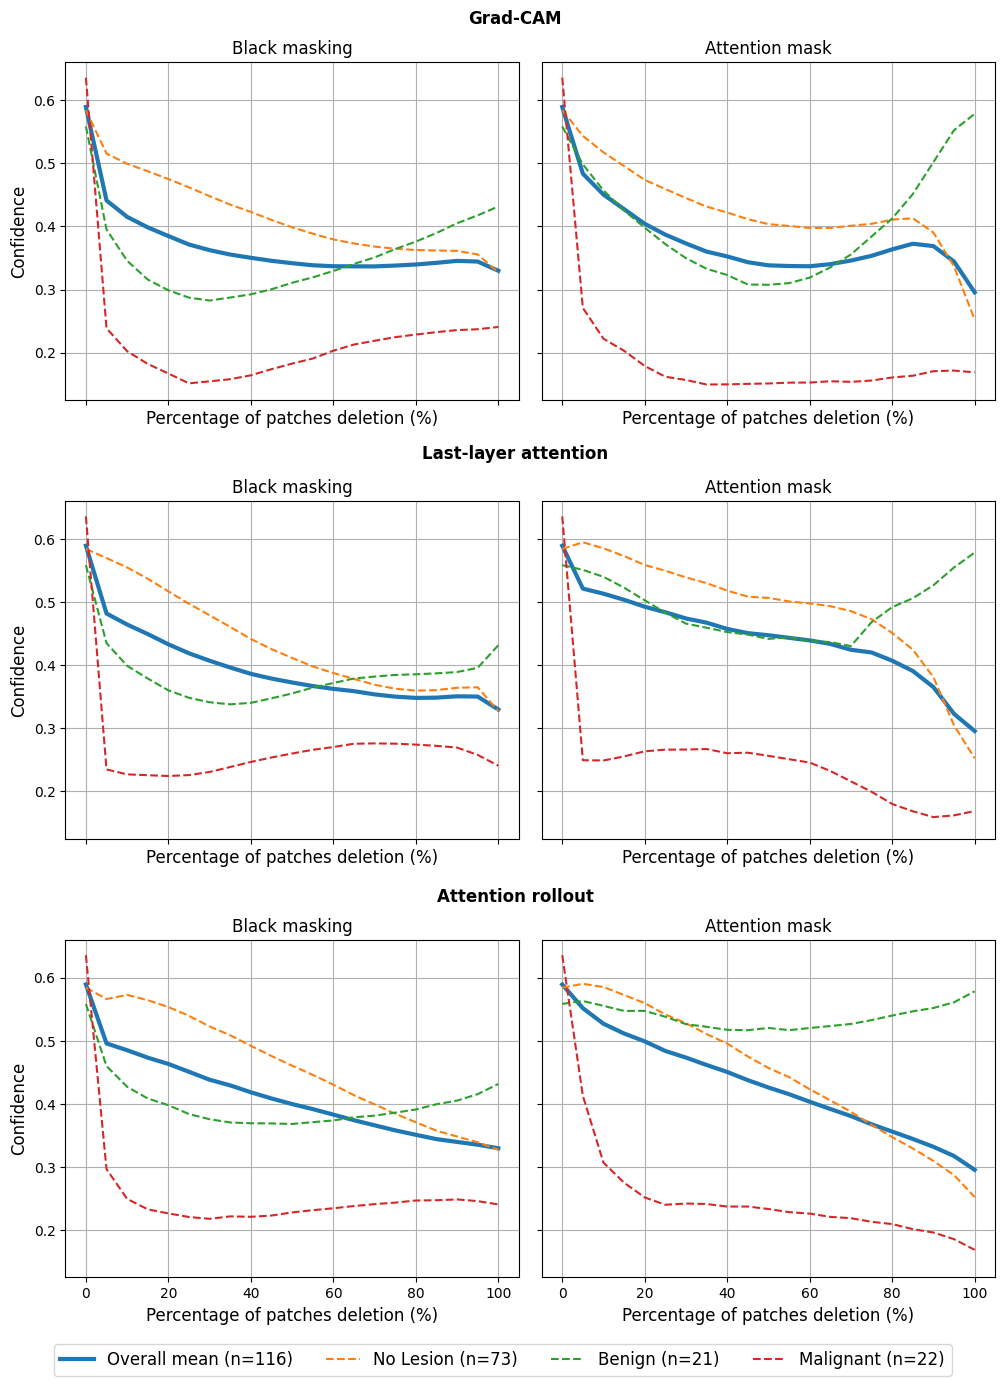

In [18]:

# =========================
# Settings
# =========================
evaluation_metric = "deletion"

selected_strategies = {
    "black-5": "Black masking",
    "attention_mask": "Attention mask"
}

# # Class colors (class-wise mean curves)
# class_colors = {
#     0: "black",
#     1: "orange",
#     2: "purple"
# }

class_names = {
    0: "No Lesion",
    1: "Benign",
    2: "Malignant"
}


OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 15),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(selected_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    for col_idx, (strategy_key, strategy_name) in enumerate(strategy_list):

        ax = axes[row_idx, col_idx]

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        all_curves = []
        class_curves = {0: [], 1: [], 2: []}
        percentages = None

        # Load all curves
        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()

            curve = data["predicted_confidences"]
            pred_class = data["predicted_class"]

            all_curves.append(curve)
            class_curves[pred_class].append(curve)

            if percentages is None:
                percentages = data["percentages"]

        if len(all_curves) == 0:
            continue

        all_curves = np.array(all_curves)

        # =========================
        # Overall mean curve
        # =========================
        overall_mean = all_curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            overall_mean,
            linewidth=3,
            label=f"Overall mean (n={len(all_curves)})"
        )

        # =========================
        # Class-wise mean curves
        # =========================
        for cls in [0, 1, 2]:
            if len(class_curves[cls]) == 0:
                continue

            class_mean = np.mean(class_curves[cls], axis=0)
            n_samples = len(class_curves[cls])

            ax.plot(
                percentages * 100,
                class_mean,
                linestyle="--",
                # linewidth=2,
                # color=class_colors[cls],
                label=f"{class_names[cls]} (n={n_samples})"
            )
        ax.set_xlabel("Percentage of patches deletion (%)", fontsize=12)
        ax.set_title(strategy_name, fontsize=12)
        ax.grid(True)

# =========================
# Shared axis labels
# =========================
for row_idx in range(3):
    axes[row_idx, 0].set_ylabel("Confidence", fontsize=12)




fig.text(
    0.5,
    0.915,
    "Grad-CAM",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)


fig.text(
    0.5,
    0.625,
    "Last-layer attention",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

fig.text(
    0.5,
    0.33,
    "Attention rollout",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

# =========================
# Global legend
# =========================
handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove duplicate labels
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=4,
    frameon=True,
    fontsize=12
)

# Increase vertical space between subplot rows
fig.subplots_adjust(
    # top=0.85,      # leave space for legend
    hspace=0.3,   # space between rows (important)
    wspace=0.05,   # space between columns
    bottom=0.07    # leave space for legend
)

plt.savefig(
    OUTPUT_DIR / "deletion_classwise_case_analysis.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

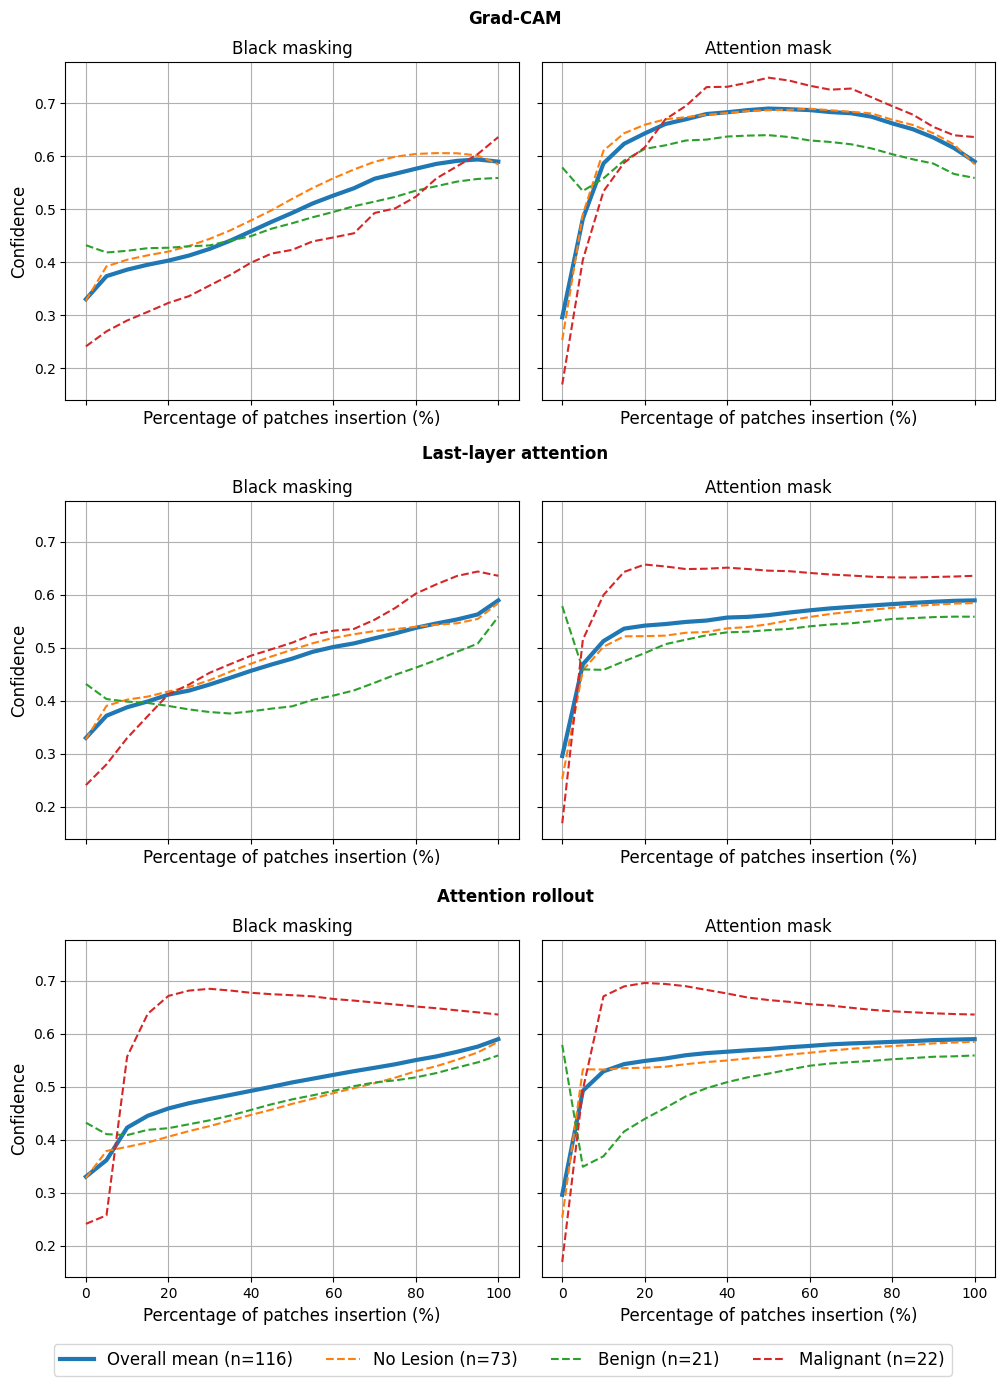

In [19]:

# =========================
# Settings
# =========================
evaluation_metric = "insertion"

selected_strategies = {
    "black-5": "Black masking",
    "attention_mask": "Attention mask"
}

# # Class colors (class-wise mean curves)
# class_colors = {
#     0: "black",
#     1: "orange",
#     2: "purple"
# }

class_names = {
    0: "No Lesion",
    1: "Benign",
    2: "Malignant"
}


OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 15),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(selected_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    for col_idx, (strategy_key, strategy_name) in enumerate(strategy_list):

        ax = axes[row_idx, col_idx]

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        all_curves = []
        class_curves = {0: [], 1: [], 2: []}
        percentages = None

        # Load all curves
        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()

            curve = data["predicted_confidences"]
            pred_class = data["predicted_class"]

            all_curves.append(curve)
            class_curves[pred_class].append(curve)

            if percentages is None:
                percentages = data["percentages"]

        if len(all_curves) == 0:
            continue

        all_curves = np.array(all_curves)

        # =========================
        # Overall mean curve
        # =========================
        overall_mean = all_curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            overall_mean,
            linewidth=3,
            label=f"Overall mean (n={len(all_curves)})"
        )

        # =========================
        # Class-wise mean curves
        # =========================
        for cls in [0, 1, 2]:
            if len(class_curves[cls]) == 0:
                continue

            class_mean = np.mean(class_curves[cls], axis=0)
            n_samples = len(class_curves[cls])

            ax.plot(
                percentages * 100,
                class_mean,
                linestyle="--",
                # linewidth=2,
                # color=class_colors[cls],
                label=f"{class_names[cls]} (n={n_samples})"
            )
        ax.set_xlabel("Percentage of patches insertion (%)", fontsize=12)
        ax.set_title(strategy_name, fontsize=12)
        ax.grid(True)

# =========================
# Shared axis labels
# =========================
for row_idx in range(3):
    axes[row_idx, 0].set_ylabel("Confidence", fontsize=12)




fig.text(
    0.5,
    0.915,
    "Grad-CAM",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)


fig.text(
    0.5,
    0.625,
    "Last-layer attention",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

fig.text(
    0.5,
    0.33,
    "Attention rollout",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

# =========================
# Global legend
# =========================
handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove duplicate labels
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=4,
    frameon=True,
    fontsize=12
)

# Increase vertical space between subplot rows
fig.subplots_adjust(
    # top=0.85,      # leave space for legend
    hspace=0.3,   # space between rows (important)
    wspace=0.05,   # space between columns
    bottom=0.07    # leave space for legend
)

plt.savefig(
    OUTPUT_DIR / "insertion_classwise_case_analysis.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

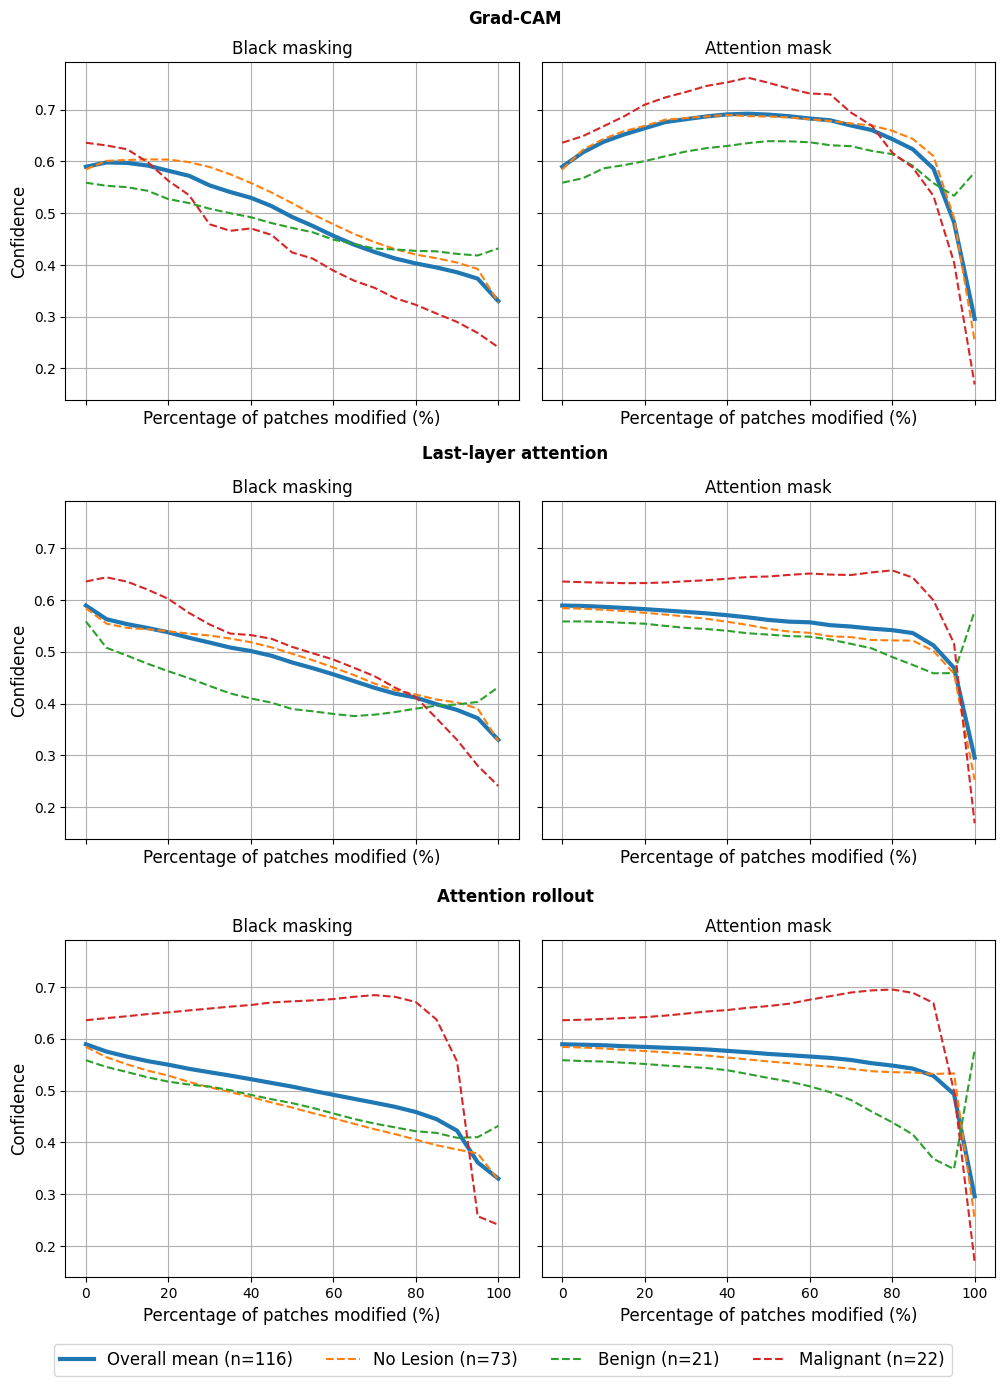

In [20]:

# =========================
# Settings
# =========================
evaluation_metric = "negative"

selected_strategies = {
    "black-5": "Black masking",
    "attention_mask": "Attention mask"
}

# # Class colors (class-wise mean curves)
# class_colors = {
#     0: "black",
#     1: "orange",
#     2: "purple"
# }

class_names = {
    0: "No Lesion",
    1: "Benign",
    2: "Malignant"
}


OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 15),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(selected_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    for col_idx, (strategy_key, strategy_name) in enumerate(strategy_list):

        ax = axes[row_idx, col_idx]

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        all_curves = []
        class_curves = {0: [], 1: [], 2: []}
        percentages = None

        # Load all curves
        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()

            curve = data["predicted_confidences"]
            pred_class = data["predicted_class"]

            all_curves.append(curve)
            class_curves[pred_class].append(curve)

            if percentages is None:
                percentages = data["percentages"]

        if len(all_curves) == 0:
            continue

        all_curves = np.array(all_curves)

        # =========================
        # Overall mean curve
        # =========================
        overall_mean = all_curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            overall_mean,
            linewidth=3,
            label=f"Overall mean (n={len(all_curves)})"
        )

        # =========================
        # Class-wise mean curves
        # =========================
        for cls in [0, 1, 2]:
            if len(class_curves[cls]) == 0:
                continue

            class_mean = np.mean(class_curves[cls], axis=0)
            n_samples = len(class_curves[cls])

            ax.plot(
                percentages * 100,
                class_mean,
                linestyle="--",
                # linewidth=2,
                # color=class_colors[cls],
                label=f"{class_names[cls]} (n={n_samples})"
            )
        ax.set_xlabel("Percentage of patches modified (%)", fontsize=12)
        ax.set_title(strategy_name, fontsize=12)
        ax.grid(True)

# =========================
# Shared axis labels
# =========================
for row_idx in range(3):
    axes[row_idx, 0].set_ylabel("Confidence", fontsize=12)




fig.text(
    0.5,
    0.915,
    "Grad-CAM",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)


fig.text(
    0.5,
    0.625,
    "Last-layer attention",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

fig.text(
    0.5,
    0.33,
    "Attention rollout",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

# =========================
# Global legend
# =========================
handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove duplicate labels
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=4,
    frameon=True,
    fontsize=12
)

# Increase vertical space between subplot rows
fig.subplots_adjust(
    # top=0.85,      # leave space for legend
    hspace=0.3,   # space between rows (important)
    wspace=0.05,   # space between columns
    bottom=0.07    # leave space for legend
)

plt.savefig(
    OUTPUT_DIR / "negative_classwise_case_analysis.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

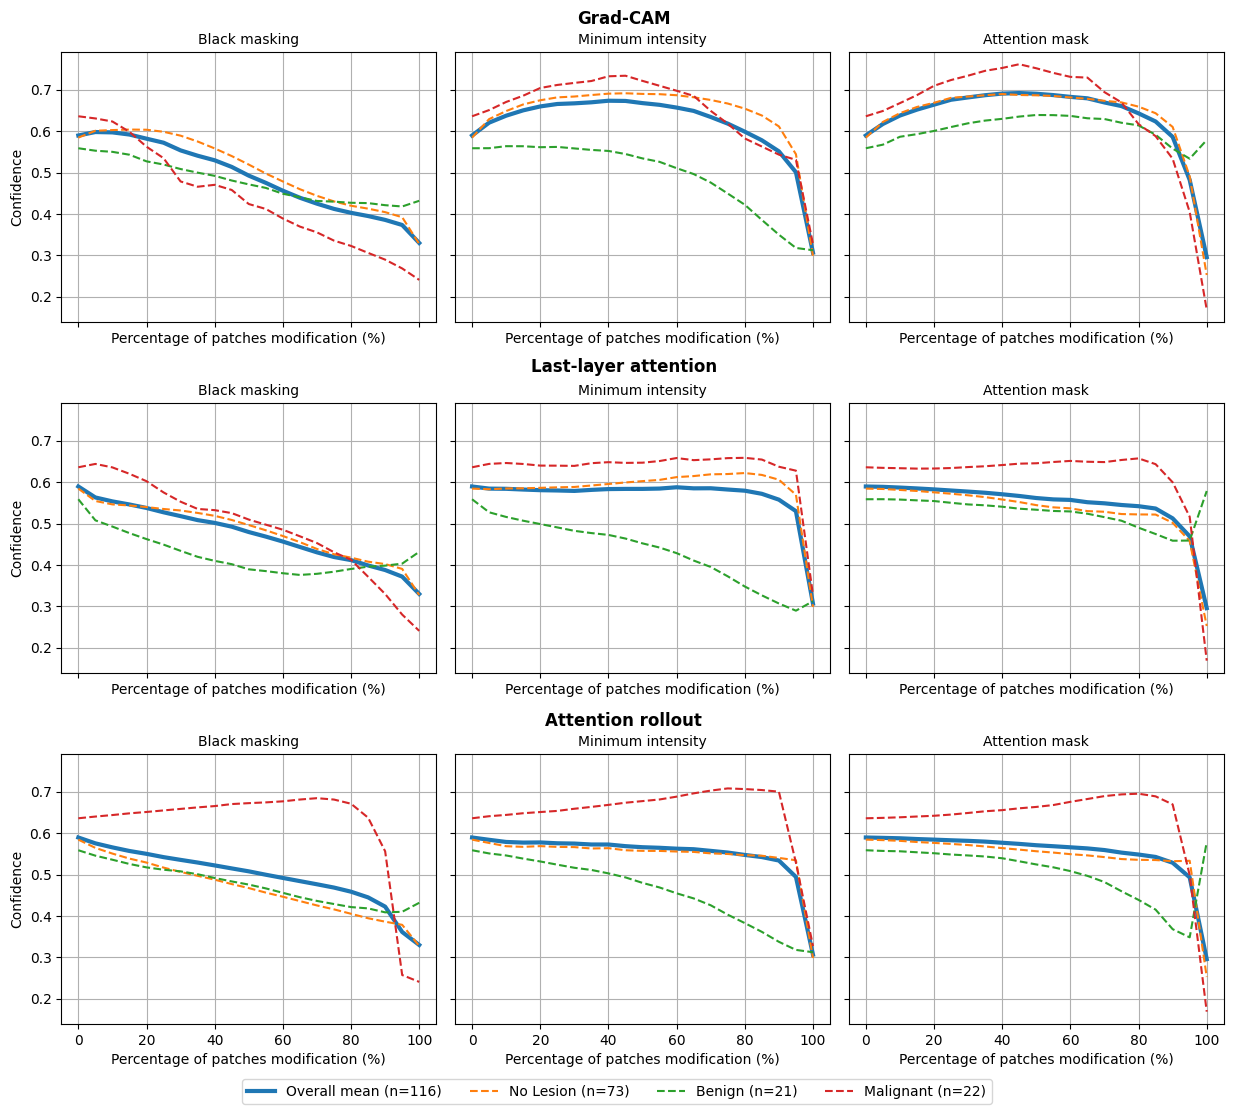

In [21]:

# =========================
# Settings
# =========================
evaluation_metric = "negative"  

selected_strategies = {
    "black-5": "Black masking",
    "minimum-intensity": "Minimum intensity",
    "attention_mask": "Attention mask"
}

# # Class colors (class-wise mean curves)
# class_colors = {
#     0: "black",
#     1: "orange",
#     2: "purple"
# }

class_names = {
    0: "No Lesion",
    1: "Benign",
    2: "Malignant"
}


OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 12),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(selected_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    for col_idx, (strategy_key, strategy_name) in enumerate(strategy_list):

        ax = axes[row_idx, col_idx]

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        all_curves = []
        class_curves = {0: [], 1: [], 2: []}
        percentages = None

        # Load all curves
        for f in curve_dir.glob("*.npy"):
            data = np.load(f, allow_pickle=True).item()

            curve = data["predicted_confidences"]
            pred_class = data["predicted_class"]

            all_curves.append(curve)
            class_curves[pred_class].append(curve)

            if percentages is None:
                percentages = data["percentages"]

        if len(all_curves) == 0:
            continue

        all_curves = np.array(all_curves)

        # =========================
        # Overall mean curve
        # =========================
        overall_mean = all_curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            overall_mean,
            linewidth=3,
            label=f"Overall mean (n={len(all_curves)})"
        )

        # =========================
        # Class-wise mean curves
        # =========================
        for cls in [0, 1, 2]:
            if len(class_curves[cls]) == 0:
                continue

            class_mean = np.mean(class_curves[cls], axis=0)
            n_samples = len(class_curves[cls])

            ax.plot(
                percentages * 100,
                class_mean,
                linestyle="--",
                # linewidth=2,
                # color=class_colors[cls],
                label=f"{class_names[cls]} (n={n_samples})"
            )
        ax.set_xlabel("Percentage of patches modification (%)")
        ax.set_title(strategy_name, fontsize=10)
        ax.grid(True)

# =========================
# Shared axis labels
# =========================
for row_idx in range(3):
    axes[row_idx, 0].set_ylabel("Confidence")




fig.text(
    0.5,
    0.915,
    "Grad-CAM",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)


fig.text(
    0.5,
    0.625,
    "Last-layer attention",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

fig.text(
    0.5,
    0.33,
    "Attention rollout",
    ha="center",
    va="top",
    fontsize=12,
    weight="bold"
)

# =========================
# Global legend
# =========================
handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove duplicate labels
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=4,
    frameon=True
)

# Increase vertical space between subplot rows
fig.subplots_adjust(
    # top=0.85,      # leave space for legend
    hspace=0.3,   # space between rows (important)
    wspace=0.05,   # space between columns
    bottom=0.07    # leave space for legend
)

plt.savefig(
    OUTPUT_DIR / "negative_classwise_case_analysis_2.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

#### Only correct classified

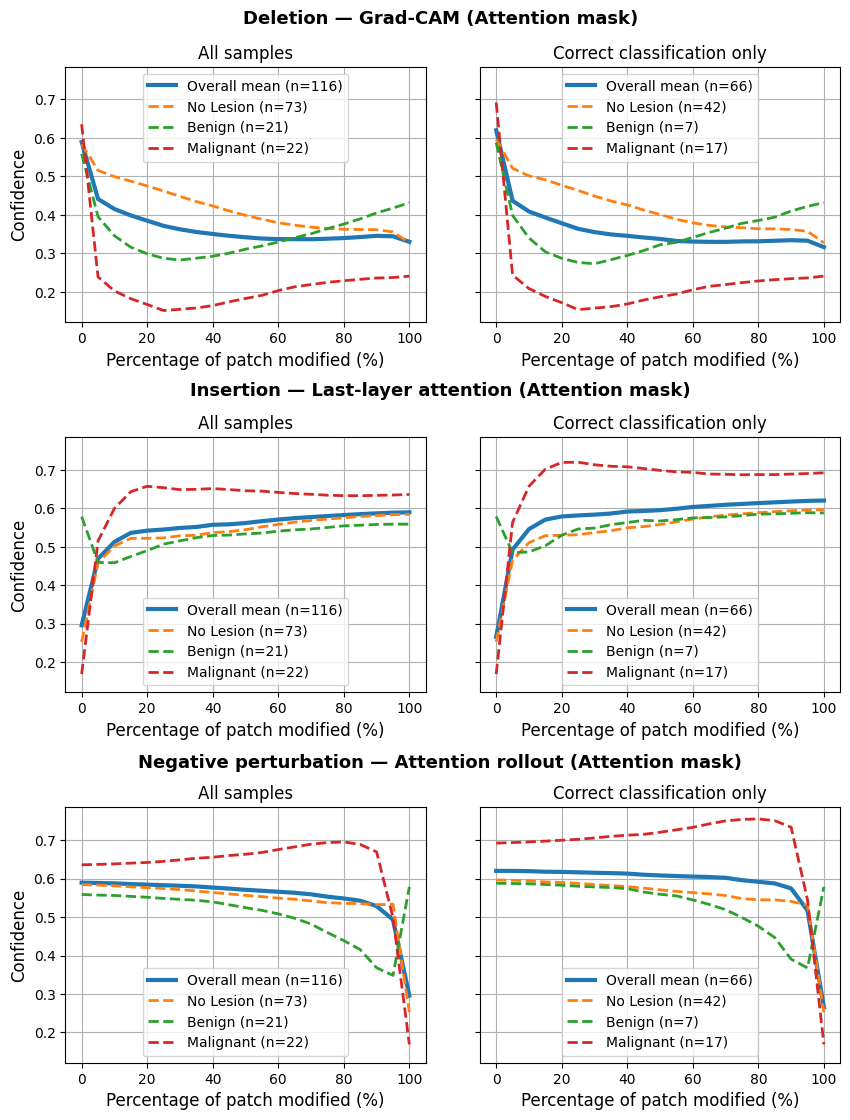

In [22]:
import json

# ==========================================
# Load correct prediction UIDs
# ==========================================
with open(
    "/home/jovyan/work/MST/scripts/Jupyter_notebook/Confusion Matrix/v3_correct_full.json",
    "r"
) as f:
    correct_data = json.load(f)

# Convert to set for fast lookup
correct_uid_set = set()

for cls in correct_data.keys():
    for item in correct_data[cls]:
        correct_uid_set.add(item["UID"])

# ==========================================
# Selected experiments
# ==========================================
selected_experiments = [
    {
        "evaluation_metric": "deletion",
        "method_key": "gradcam",
        "method_name": "Grad-CAM",
        "strategy_key": "black-5",
        "strategy_name": "Attention mask",
        # "strategy_name": "Black masking"
    },
    {
        "evaluation_metric": "insertion",
        "method_key": "last_layer",
        "method_name": "Last-layer attention",
        "strategy_key": "attention_mask",
        "strategy_name": "Attention mask"
    },
    {
        "evaluation_metric": "negative",
        "method_key": "slice_weighted_rollout",
        "method_name": "Attention rollout",
        "strategy_key": "attention_mask",
        "strategy_name": "Attention mask"
    }
]

# ==========================================
# Plot settings
# ==========================================
OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

class_names = {
    0: "No Lesion",
    1: "Benign",
    2: "Malignant"
}

class_colors = {
    0: "tab:orange",
    1: "tab:green",
    2: "tab:red"
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(10, 12),
    sharex=False,
    sharey=True
)

# ==========================================
# Main loop
# ==========================================
for row_idx, exp in enumerate(selected_experiments):

    curve_dir = (
        base_path
        / exp["evaluation_metric"]
        / f"{exp['evaluation_metric']}_curves"
        / exp["method_key"]
        / exp["strategy_key"]
    )

    all_curves_all = []
    all_curves_correct = []

    class_curves_all = {0: [], 1: [], 2: []}
    class_curves_correct = {0: [], 1: [], 2: []}

    percentages = None

    for f in curve_dir.glob("*.npy"):

        data = np.load(f, allow_pickle=True).item()

        uid = f.name.split("_curve_")[0]
        curve = data["predicted_confidences"]
        pred_class = data["predicted_class"]

        if percentages is None:
            percentages = data["percentages"]

        # ---------- All samples ----------
        all_curves_all.append(curve)
        class_curves_all[pred_class].append(curve)

        # ---------- Correct only ----------
        if uid in correct_uid_set:
            all_curves_correct.append(curve)
            class_curves_correct[pred_class].append(curve)

    plot_data = [
        ("All samples", all_curves_all, class_curves_all),
        ("Correct classification only", all_curves_correct, class_curves_correct)
    ]

    for col_idx, (title, overall_curves, class_curves) in enumerate(plot_data):

        ax = axes[row_idx, col_idx]

        overall_curves = np.array(overall_curves)

        # Overall mean
        overall_mean = overall_curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            overall_mean,
            linewidth=3,
            label=f"Overall mean (n={len(overall_curves)})"
        )

        # Class-wise means
        for cls in [0, 1, 2]:

            if len(class_curves[cls]) == 0:
                continue

            class_mean = np.mean(class_curves[cls], axis=0)

            ax.plot(
                percentages * 100,
                class_mean,
                linestyle="--",
                linewidth=2,
                color=class_colors[cls],
                label=f"{class_names[cls]} (n={len(class_curves[cls])})"
            )

        ax.set_title(title)
        ax.set_xlabel(
            "Percentage of patch modified (%)", fontsize=12
        )
        # ax.set_ylabel("Confidence", fontsize=12)
        ax.grid(True)
    axes[row_idx, 0].set_ylabel("Confidence", fontsize=12)
    
    # Row title
    fig.text(
        0.5,
        0.92 - row_idx * 0.31,
        f"{exp['evaluation_metric'].capitalize()} — {exp['method_name']} ({exp['strategy_name']})" if exp["evaluation_metric"] in ["deletion", "insertion"] else "Negative perturbation — " + \
        f"{exp['method_name']} ({exp['strategy_name']})",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )

# ==========================================
# Legend
# ==========================================
# ==========================================
# Local legends (per subplot)
# ==========================================
for row_idx in range(3):
    for col_idx in range(2):

        ax = axes[row_idx, col_idx]

        handles, labels = ax.get_legend_handles_labels()

        # remove duplicates inside subplot
        unique = dict(zip(labels, handles))

        ax.legend(
            unique.values(),
            unique.keys(),
            loc="upper center" if ax == axes[0, 0] or ax == axes[0, 1] else "lower center",
            fontsize=10,
            frameon=True
        )
# ==========================================
# Layout
# ==========================================
fig.subplots_adjust(
    hspace=0.45,
    wspace=0.15,
    bottom=0.05
)

plt.savefig(
    OUTPUT_DIR / "all_vs_correct_classwise_comparison.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Modification Method Analysis

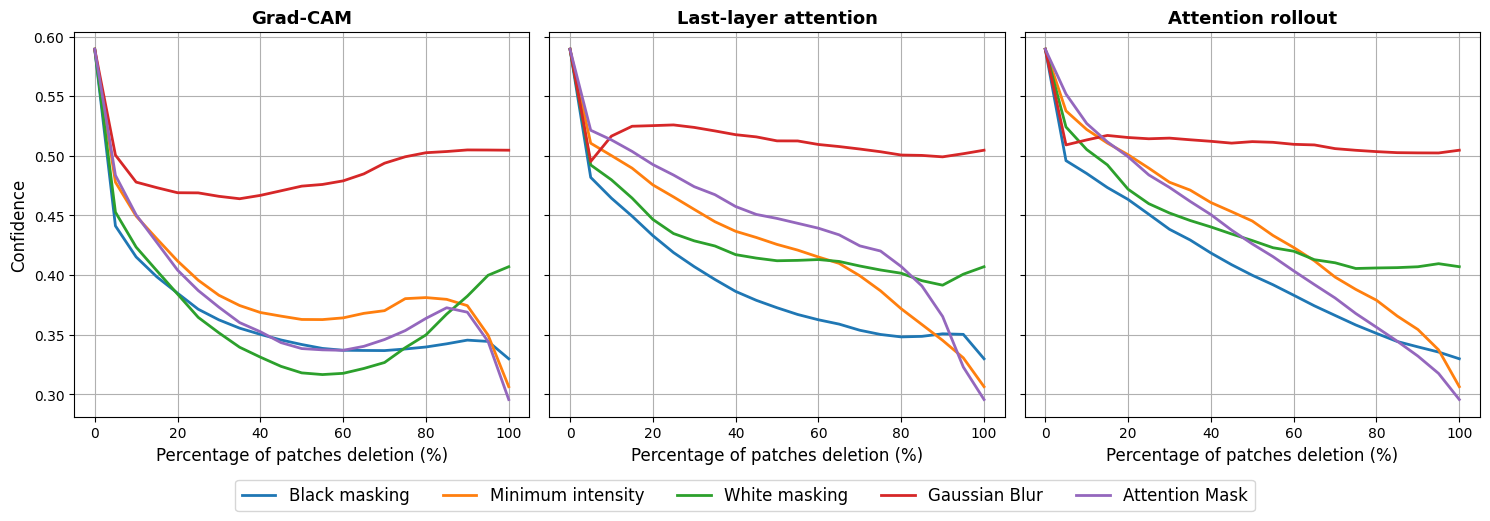

In [23]:
evaluation_metric = "deletion"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(replacement_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    ax = axes[row_idx]

    for strategy_key, strategy_name in strategy_list:

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):

            data = np.load(f, allow_pickle=True).item()

            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)

        mean_curve = curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            mean_curve,
            label=strategy_name,
            linewidth=2
        )

    # Plot formatting
    ax.set_title(
        method_name,
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel(
        f"Percentage of patches {evaluation_metric} (%)",
        fontsize=12
    )
    ax.grid(True)

# # Shared Y label
axes[0].set_ylabel("Confidence", fontsize=12)

# =========================
# Global legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=12
)

# Layout (reserve space for legend)
plt.tight_layout(
    rect=[0, 0.03, 1, 1]
)

# Save
plt.savefig(
    OUTPUT_DIR / f"{evaluation_metric}_strategy_comparison_per_xai.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

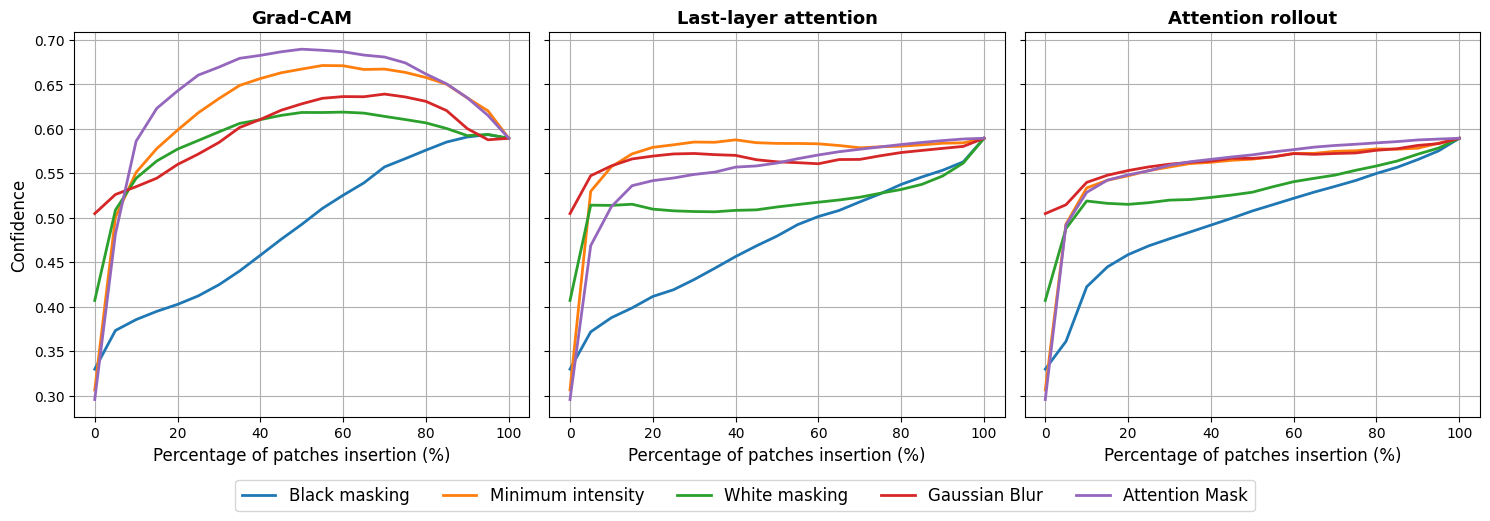

In [24]:
evaluation_metric = "insertion"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(replacement_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    ax = axes[row_idx]

    for strategy_key, strategy_name in strategy_list:

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):

            data = np.load(f, allow_pickle=True).item()

            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)

        mean_curve = curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            mean_curve,
            label=strategy_name,
            linewidth=2
        )

    # Plot formatting
    ax.set_title(
        method_name,
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel(
        f"Percentage of patches {evaluation_metric} (%)", fontsize=12
    )
    ax.grid(True)

# Shared Y label
axes[0].set_ylabel("Confidence", fontsize=12)

# =========================
# Global legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=12
)

# Layout (reserve space for legend)
plt.tight_layout(
    rect=[0, 0.03, 1, 1]
)

# Save
plt.savefig(
    OUTPUT_DIR / f"{evaluation_metric}_strategy_comparison_per_xai.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

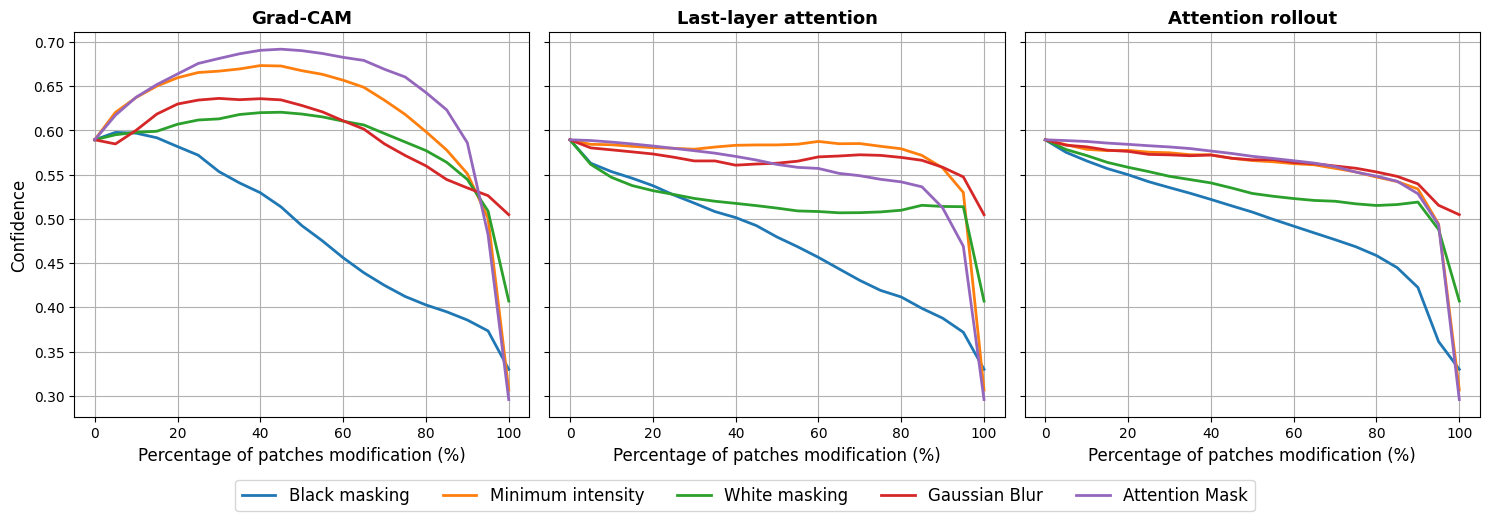

In [25]:
evaluation_metric = "negative"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

xai_list = list(xai_methods.items())
strategy_list = list(replacement_strategies.items())

# =========================
# Main loop
# =========================
for row_idx, (method_key, method_name) in enumerate(xai_list):

    ax = axes[row_idx]

    for strategy_key, strategy_name in strategy_list:

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):

            data = np.load(f, allow_pickle=True).item()

            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)

        mean_curve = curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            mean_curve,
            label=strategy_name,
            linewidth=2
        )

    # Plot formatting
    ax.set_title(
        method_name,
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel(
        f"Percentage of patches modification (%)",
        fontsize=12
    )
    ax.grid(True)

# Shared Y label
axes[0].set_ylabel("Confidence", fontsize=12)

# =========================
# Global legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=12
)

# Layout (reserve space for legend)
plt.tight_layout(
    rect=[0, 0.03, 1, 1]
)

# Save
plt.savefig(
    OUTPUT_DIR / f"{evaluation_metric}_strategy_comparison_per_xai.jpg",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

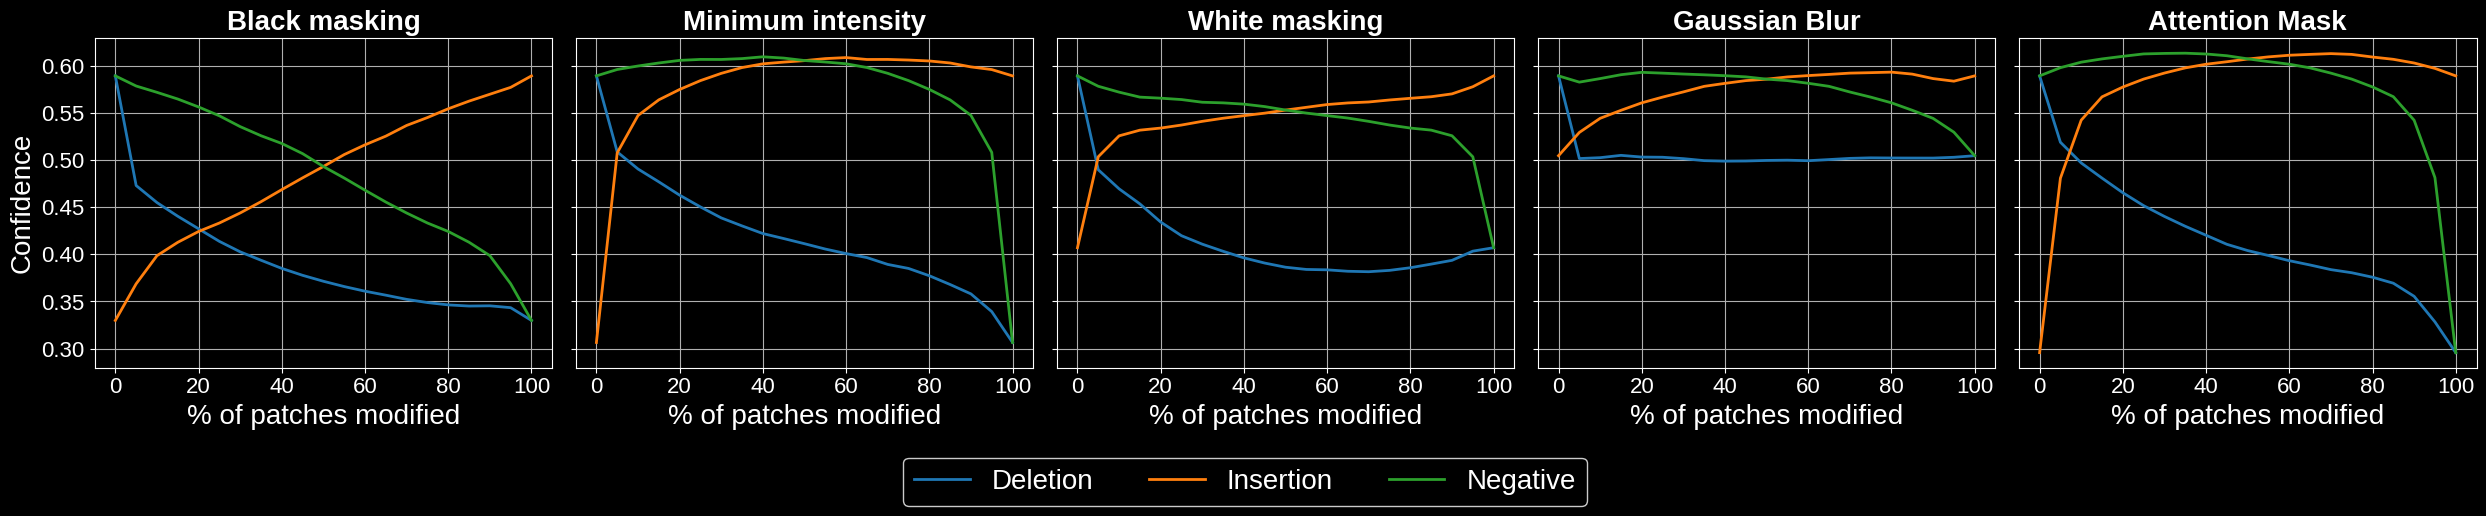

In [44]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rcParams["font.family"] = "Liberation Sans"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

evaluation_metrics = ["deletion", "insertion", "negative"]

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(replacement_strategies),
    figsize=(25, 5),
    sharex=True,
    sharey=True
)

fig.patch.set_facecolor("black")
for ax in axes:
    ax.set_facecolor("black")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(
        axis= "both",
        colors="white",
        labelsize=16)
    for spine in ax.spines.values():
        spine.set_color("white")

strategy_list = list(replacement_strategies.items())
xai_list = list(xai_methods.items())

# =========================
# Main loop
# =========================
for col_idx, (strategy_key, strategy_name) in enumerate(strategy_list):

    ax = axes[col_idx]

    for evaluation_metric in evaluation_metrics:

        all_curves = []
        percentages = None

        # collect curves across all XAI methods
        for method_key, method_name in xai_list:

            curve_dir = (
                base_path
                / evaluation_metric
                / f"{evaluation_metric}_curves"
                / method_key
                / strategy_key
            )

            for f in curve_dir.glob("*.npy"):

                data = np.load(f, allow_pickle=True).item()

                all_curves.append(data["predicted_confidences"])

                if percentages is None:
                    percentages = data["percentages"]

        if len(all_curves) == 0:
            continue

        all_curves = np.array(all_curves)
        mean_curve = all_curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            mean_curve,
            label=evaluation_metric.capitalize(),
            linewidth=2
        )

    # Plot formatting
    ax.set_title(
        strategy_name,
        fontsize=20,
        fontweight="bold"
    )

    ax.set_xlabel(
        "% of patches modified",
        fontsize=20
    )

    ax.grid(True)

# Shared Y label
axes[0].set_ylabel("Confidence", fontsize=20)

# Global legend
handles, labels = axes[0].get_legend_handles_labels()

legend = fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=20
)

legend.get_frame().set_facecolor("black")
legend.get_frame().set_edgecolor("white")

for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout(rect=[0, 0.1, 1, 1])

plt.savefig(
    OUTPUT_DIR / "strategy_comparison_per_metric.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [42]:
import matplotlib.font_manager as fm

fonts = sorted(set(f.name for f in fm.fontManager.ttflist))
print(fonts)

['C059', 'D050000L', 'DejaVu Math TeX Gyre', 'DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Serif Display', 'Inconsolata', 'Liberation Mono', 'Liberation Sans', 'Liberation Sans Narrow', 'Liberation Serif', 'Nimbus Mono PS', 'Nimbus Roman', 'Nimbus Sans', 'Nimbus Sans Narrow', 'P052', 'STIXGeneral', 'STIXNonUnicode', 'STIXSizeFiveSym', 'STIXSizeFourSym', 'STIXSizeOneSym', 'STIXSizeThreeSym', 'STIXSizeTwoSym', 'Source Code Pro', 'Standard Symbols PS', 'URW Bookman', 'URW Gothic', 'Ubuntu', 'Ubuntu Condensed', 'Ubuntu Mono', 'Z003', 'cmb10', 'cmex10', 'cmmi10', 'cmr10', 'cmss10', 'cmsy10', 'cmtt10']


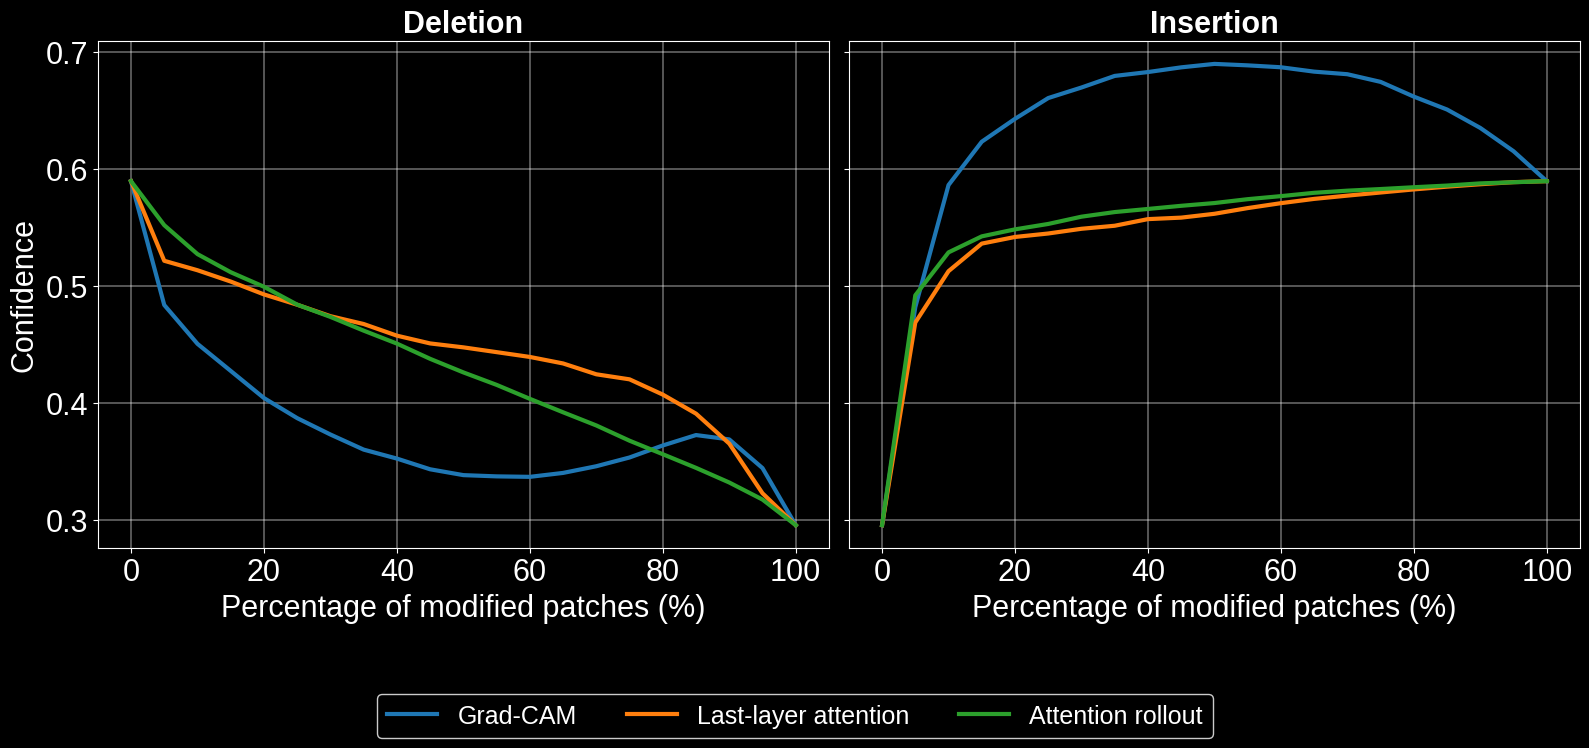

In [48]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Liberation Sans"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

evaluation_metrics = ["deletion", "insertion"]
strategy_key = "attention_mask"   # replace with actual key
strategy_name = "Attention Mask"

# =========================
# Figure setup
# =========================
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7),
    sharey=True
)

# black background
fig.patch.set_facecolor("black")

for ax in axes:
    ax.set_facecolor("black")

    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")

    ax.tick_params(
        axis="both",
        colors="white",
        labelsize=22
    )

    for spine in ax.spines.values():
        spine.set_color("white")

# =========================
# Loop over metrics
# =========================
for idx, evaluation_metric in enumerate(evaluation_metrics):

    ax = axes[idx]

    for method_key, method_name in xai_methods.items():

        curve_dir = (
            base_path
            / evaluation_metric
            / f"{evaluation_metric}_curves"
            / method_key
            / strategy_key
        )

        curves = []
        percentages = None

        for f in curve_dir.glob("*.npy"):

            data = np.load(f, allow_pickle=True).item()

            curves.append(data["predicted_confidences"])

            if percentages is None:
                percentages = data["percentages"]

        if len(curves) == 0:
            continue

        curves = np.array(curves)
        mean_curve = curves.mean(axis=0)

        ax.plot(
            percentages * 100,
            mean_curve,
            label=method_name,
            linewidth=3
        )

    ax.set_title(
        evaluation_metric.capitalize(),
        fontsize=22,
        color="white",
        fontweight="bold"
    )

    ax.set_xlabel(
        "Percentage of modified patches (%)",
        fontsize=22
    )

    ax.grid(
    True,
    color="white",
    alpha=0.4,
    linewidth=1.2
    )

# Shared Y label
axes[0].set_ylabel(
    "Confidence",
    fontsize=22
)

# Legend (single shared legend)
handles, labels = axes[0].get_legend_handles_labels()

legend = fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(xai_methods),
    frameon=True,
    bbox_to_anchor=(0.5, -0.08),
    fontsize=18
)

legend.get_frame().set_facecolor("black")
legend.get_frame().set_edgecolor("white")

for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    OUTPUT_DIR / "attention_mask_deletion_insertion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

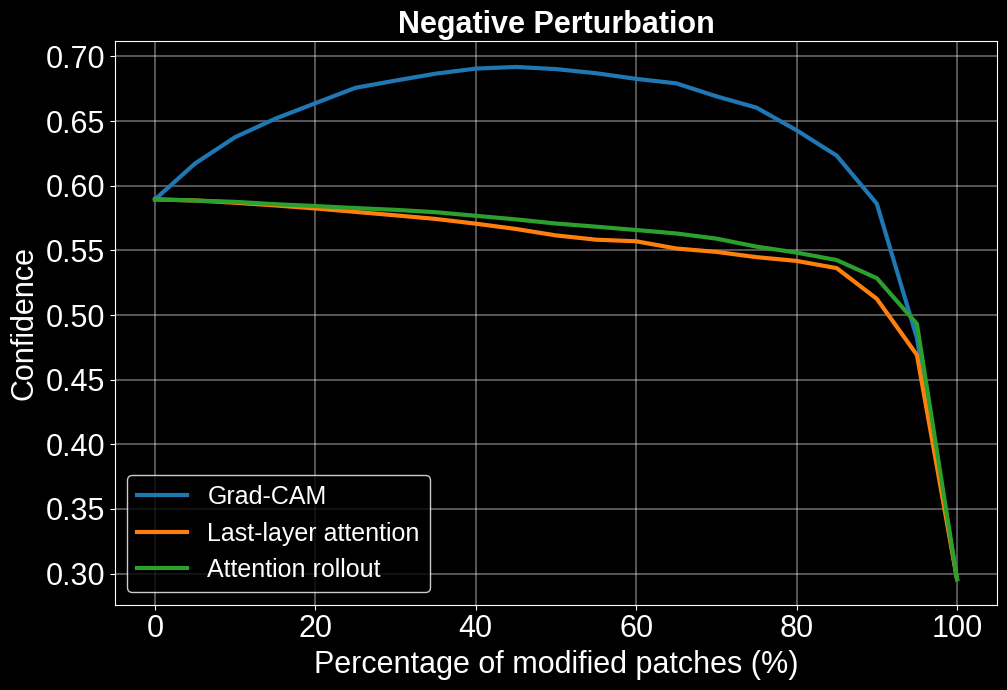

In [50]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Liberation Sans"

OUTPUT_DIR = Path("perturbation_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

evaluation_metric = "negative"
strategy_key = "attention_mask"
strategy_name = "Attention Mask"

# =========================
# Figure setup
# =========================
fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 7)
)

# black background
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")

ax.tick_params(
    axis="both",
    colors="white",
    labelsize=22
)

for spine in ax.spines.values():
    spine.set_color("white")

# =========================
# Loop over XAI methods
# =========================
for method_key, method_name in xai_methods.items():

    curve_dir = (
        base_path
        / evaluation_metric
        / f"{evaluation_metric}_curves"
        / method_key
        / strategy_key
    )

    curves = []
    percentages = None

    for f in curve_dir.glob("*.npy"):

        data = np.load(f, allow_pickle=True).item()

        curves.append(data["predicted_confidences"])

        if percentages is None:
            percentages = data["percentages"]

    if len(curves) == 0:
        continue

    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)

    ax.plot(
        percentages * 100,
        mean_curve,
        label=method_name,
        linewidth=3
    )

# =========================
# Styling
# =========================
ax.set_title(
    "Negative Perturbation",
    fontsize=22,
    color="white",
    fontweight="bold"
)

ax.set_xlabel(
    "Percentage of modified patches (%)",
    fontsize=22
)

ax.set_ylabel(
    "Confidence",
    fontsize=22
)

ax.grid(
    True,
    color="white",
    alpha=0.4,
    linewidth=1.2
)

legend = ax.legend(
    fontsize=18,
    frameon=True
)

legend.get_frame().set_facecolor("black")
legend.get_frame().set_edgecolor("white")

for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "attention_mask_negative.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()